
# A Data Scientist's Guide to Microeconomics — From Demand Theory to Agentic Pricing

Data science and microeconomics each have their own languages and tools, yet the questions they explore frequently overlap. Price is a natural place to explore how the two connect. This article walks through microeconomic fundamentals with a data scientist in mind, and builds toward an agentic pricing system that draws from both worlds.


> *Bayesian workflow:* model code follows `.skills/bayesian-workflow/SKILL.md`. Consult it before modifying any PyMC block.

**Stack:** PyMC 5 · ArviZ · EconML (Double ML) · scikit-learn · statsmodels


In [2]:
## 0. Setup and Imports

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import pymc as pm
import arviz as az
from econml.dml import LinearDML


# Reproducible seed (bayesian-workflow: descriptive, derived from analysis name)
RANDOM_SEED = sum(map(ord, "price-curves-agents-v3"))
rng = np.random.default_rng(RANDOM_SEED)

# Plotting defaults
sns.set_theme(style="whitegrid", palette="colorblind", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

print(f"PyMC  : {pm.__version__}")
print(f"ArviZ : {az.__version__}")
print(f"Seed  : {RANDOM_SEED}")
print("Ready.")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


PyMC  : 5.28.1
ArviZ : 0.23.4
Seed  : 2141
Ready.


# Introduction

Let us start with a definition that will anchor everything that follows.

**Price is often endogenous.** In markets where firms have pricing power — the ability to influence the price they charge rather than simply accept what the market dictates — price is not an external input you observe and regress against. It is a variable determined inside the system, simultaneously shaped by and shaping every other quantity in the market. When you raise a price, the quantity sold changes. When the quantity sold changes, your next pricing decision changes. When your pricing decision changes, your competitor reacts. When your competitor reacts, the demand you face shifts. The circle closes. In those markets, this is not a theoretical nuance — it is the most consequential assumption behind the variable you are trying to model.

And it is this assumption that most machine-learning pipelines quietly bypass: price appears in the model as a feature, often with rich controls, but the data it was trained on was generated by a process where prices and outcomes were determined together — a circularity that correlation alone cannot untangle.

### Where the Feedback Loop Shows Up

This feedback loop appears across familiar data-science problems, but the way price participates is qualitatively different from other cases.

In demand forecasting, the model predicts how much will sell, and that prediction drives inventory and pricing actions, which in turn change what sells — the forecast, in a sense, reshapes its own ground truth. In dynamic pricing, an algorithm observes demand conditions, sets a price, and then finds itself learning from a world it has already altered — a subtler challenge than simply reading signals from the outside. In credit scoring or fraud detection, something similar happens: denying credit tends to change future application pools; catching fraud gradually shifts attacker behaviour.

What makes price a little different — or at least worth treating separately — is how directly and immediately the feedback operates. Credit and fraud models act more like filters: they accept or reject individual cases, and whatever follows tends to unfold over weeks, through channels that are somewhat removed from the original decision. Price sits closer to the system's core. When a pricing algorithm changes a price, quantity demanded tends to shift in that same transaction, revenue in that same period. The feedback doesn't feel like a distant consequence — it feels more like part of the mechanism itself, running continuously in the background.

### Why This Requires a Different Framework

Consider what Christopher Bishop's definition of machine learning asks us to do: learn a mapping from inputs to outputs using data, optimising some loss on held-out examples. That paradigm works well when the inputs are given and the world holds still between training and inference. Price unsettles both assumptions. It is a decision variable — an output of your system that re-enters as an input. Neither does the world hold still: the act of setting a price today quietly reshapes the distribution of outcomes tomorrow.

This is, in a sense, a different kind of problem — one that economics has been turning over for two centuries. Microeconomics, at its core, is the study of how individuals and firms make decisions under scarcity, and what those decisions collectively produce. At the centre of that inquiry sits price: not as a number to be predicted, but as a signal — one that simultaneously reflects what consumers want, what producers are willing to supply, and the tension between the two that markets are always trying to resolve.

### The Thesis

The argument of this article is that data science and microeconomics share deeper roots than either field typically acknowledges — and that those shared roots, once made explicit, are practically useful.

Microeconomic structure explains *why* certain pricing algorithms converge and others oscillate. It provides the equations to diagnose pricing power, predict competitive response, and evaluate welfare consequences. It reveals that the dynamic pricing algorithms data-science teams deploy are, without quite realising it, producing the exact kind of exogenous variation that economists have searched for since the 1920s — making them natural allies in the identification problem.

At the same time, the connection runs in both directions. The computational tools that data scientists bring — Bayesian inference, causal machine learning, bandit algorithms — give microeconomic theory an operational backbone it historically lacked. The two fields are not merely complementary; they are, in a meaningful sense, working on the same problem from different ends.

This article traces those connections and then projects forward: as agentic AI systems begin to absorb both the economic reasoning and the algorithmic machinery, the boundary between the two disciplines dissolves further, and a more holistic approach to pricing becomes possible.

Here is the plan:

1. **The Role Price Plays** — Demand, supply, equilibrium, and what happens when the system is shocked. The microeconomic foundation, told for data scientists.
2. **Elasticity: The Number That Runs the Business** — Price elasticity of demand and supply. Why curve shapes determine strategy. Why elasticity is hard to estimate — and why that difficulty is the bridge to everything else.
3. **Price Setting in Practice** — Multi-armed bandits with covariates for dynamic pricing. Double Machine Learning for causal elasticity from observational data. Two approaches, examined through the lens of the theory we've built.
4. **Connecting Both Worlds** — The pricing agent as instrumentalist. Economic theory as the explanation for algorithmic convergence and failure. The limitations of classical tools on capturing full supply-demand dynamics.
5. **The Frontier: Agentic Price Setting** — Where classical algorithms hit their ceiling and agentic reasoning picks up.


## 1.1 Demand

The **demand curve** answers a relevant question in pricing: *how does the quantity consumers want to buy respond to price?*

Imagine a streaming service exploring what happens to its subscriber base at different monthly fees. At \$8, nearly everyone who's ever considered subscribing signs up. At \$25, only the most committed fans remain. The demand curve traces out that relationship, point by point.

Formally, the demand function $Q_D(p)$ maps price to quantity demanded. For a subscription service with a large addressable market:

$$Q_D(p) = N \cdot \Pr[\text{subscribe} \mid \text{price} = p]$$

where $N$ is the size of the addressable market. For the simulations that follow, we work with the quantity $Q_D$ directly — a linear specification $Q_D = a - bp$ with $a = 10{,}000$ and $b = 350$ — which implicitly encodes both the market size and how conversion decays with price.

The **Law of Demand** states: *consumers demand more of a good the lower its price*, holding constant tastes, the prices of other goods, and other factors that influence consumption. In virtually all real markets, the demand curve slopes downward.

A subtle but important distinction: a price change moves you along the demand curve. A change in anything else — income, preferences, competitor prices, seasonality — shifts the entire curve left or right. This distinction will matter when we try to recover the curve from observed data.

**Why price lives on the vertical axis.** In microeconomics, the convention is to plot price on the Y-axis and quantity on the X-axis. This may look backwards to a data scientist used to putting the "independent variable" on X. The reason is conceptual: in a competitive market, price is not freely chosen by any single agent — it is *determined* by the intersection of supply and demand. Price is the endogenous variable, the *outcome* of the market mechanism. Placing it on Y reflects its status as the variable the system solves for. We follow this convention from bottom-up.


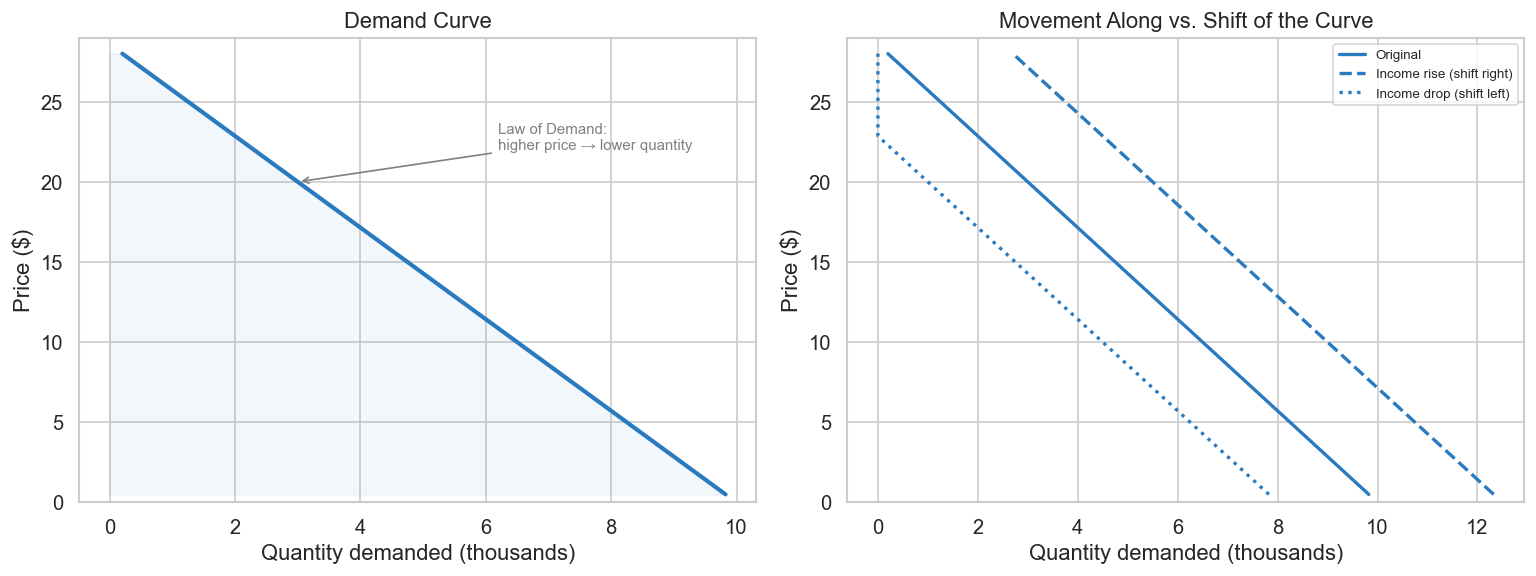

Left: demand slopes down (law of demand). Price on Y-axis per econ convention.
Right: income changes SHIFT the curve; price changes move you ALONG it.


In [3]:
## 1.1a  The Demand Curve

# Linear demand: Q = a - b*p (pedagogical — elasticity varies along this curve)
a_d, b_d = 10_000, 350

def demand(p, a=a_d, b=b_d):
    return np.maximum(a - b * p, 0)

prices = np.linspace(0.5, 28, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Demand curve (price on Y-axis, quantity on X-axis — econ convention)
ax = axes[0]
Q_vals = demand(prices)
ax.plot(Q_vals / 1_000, prices, color="#2a7abf", lw=2.5)
ax.fill_betweenx(prices, Q_vals / 1_000, alpha=0.06, color="#2a7abf")
ax.set_ylabel("Price ($)")
ax.set_xlabel("Quantity demanded (thousands)")
ax.set_title("Demand Curve")
ax.annotate("Law of Demand:\nhigher price → lower quantity",
            xy=(demand(20)/1000, 20), xytext=(demand(8)/1000 - 1, 22),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=9, color="gray")
ax.set_ylim(0, 29)

# Panel 2: Shift of demand curve (income increase shifts right)
ax = axes[1]
for a_shift, label, ls in [(a_d, "Original", "-"),
                             (a_d + 2500, "Income rise (shift right)", "--"),
                             (a_d - 2000, "Income drop (shift left)", ":")]:
    Q_s = demand(prices, a=a_shift)
    ax.plot(Q_s / 1_000, prices, color="#2a7abf", lw=2, linestyle=ls, label=label)

ax.set_ylabel("Price ($)")
ax.set_xlabel("Quantity demanded (thousands)")
ax.set_title("Movement Along vs. Shift of the Curve")
ax.legend(fontsize=8)
ax.set_ylim(0, 29)

plt.tight_layout()
plt.savefig("fig_01_demand.png", dpi=130, bbox_inches="tight")
plt.show()

print("Left: demand slopes down (law of demand). Price on Y-axis per econ convention.")
print("Right: income changes SHIFT the curve; price changes move you ALONG it.")

## 1.2 Supply

The **supply curve** $Q_S(p)$ tells you how much producers are willing to sell at a given price. For physical goods, it slopes upward: higher prices make production more attractive, drawing more output and new entrants. For digital goods — streaming subscriptions, SaaS seats, ad impressions — marginal cost is typically low relative to physical goods, though it varies: compute-heavy products and content licensing can make it far from negligible.

Supply depends on input costs (wages, materials, cloud compute), technology, the number of firms, expectations, and regulation. Just as with demand, a price change moves you **along** the supply curve; a change in any other factor **shifts** it.

For a data scientist, the supply side is where your **cost structure** lives. COGS, content licensing, server costs per subscriber, fulfilment costs per order — these are all supply-side objects. Whenever you optimise a pricing model subject to a margin constraint, you are implicitly working with a supply curve, even if you never call it that.

Again, price is plotted on the vertical axis — it is the variable the market mechanism determines, not one that any single agent controls in isolation.

**A note on our simulations.** The code throughout this article uses a linear, upward-sloping supply curve ($Q_S = -2{,}000 + 500p$). This is deliberately chosen to illustrate the full supply-demand framework — equilibrium, surplus, comparative statics — in a setting where both curves have meaningful slope and both sides constrain the outcome. A nearly flat digital-goods supply curve would make the equilibrium analysis degenerate: surplus would be almost entirely on the producer side, and comparative statics would be demand-dominated. We use the physical-goods specification for pedagogical clarity, with the understanding that readers working on digital products should adapt the supply side to reflect their near-zero marginal cost structure.

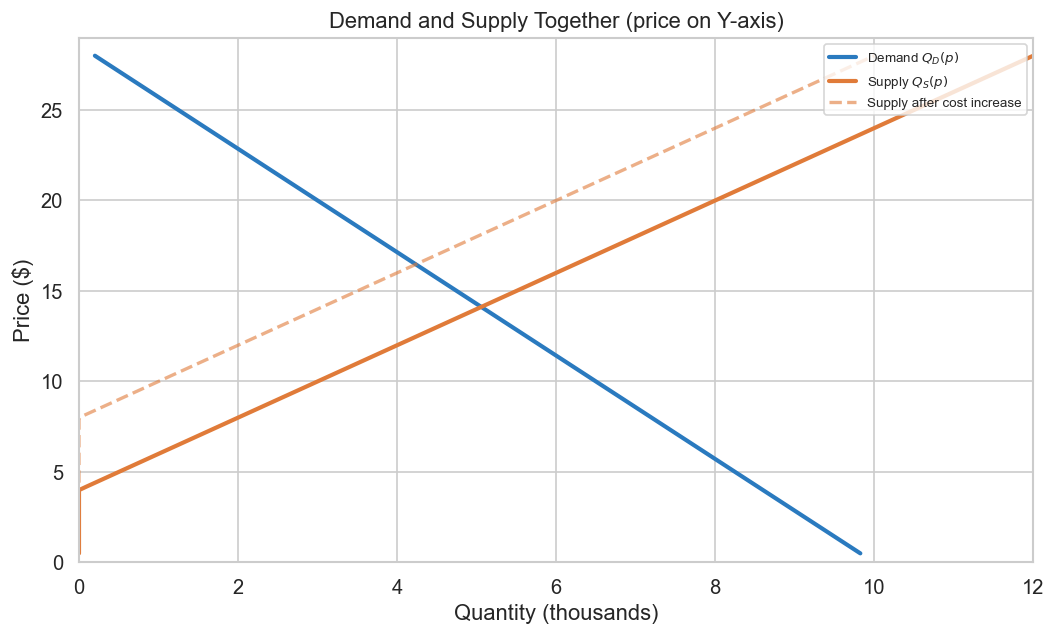

In [4]:
## 1.2a  The Supply Curve

# Linear supply: Q_S = c + d*p (upward sloping)
c_s, d_s = -2_000, 500

def supply(p, c=c_s, d=d_s):
    return np.maximum(c + d * p, 0)

fig, ax = plt.subplots(figsize=(9, 5.5))

# Price on Y-axis, Quantity on X-axis
ax.plot(demand(prices) / 1_000, prices, color="#2a7abf", lw=2.5, label="Demand $Q_D(p)$")
ax.plot(supply(prices) / 1_000, prices, color="#e07b39", lw=2.5, label="Supply $Q_S(p)$")

# Shift: input cost increase shifts supply left
ax.plot(supply(prices, c=-4_000) / 1_000, prices, color="#e07b39", lw=2,
        linestyle="--", alpha=0.6, label="Supply after cost increase")

ax.set_ylabel("Price ($)")
ax.set_xlabel("Quantity (thousands)")
ax.set_title("Demand and Supply Together (price on Y-axis)")
ax.legend(fontsize=8, loc="upper right")
ax.set_ylim(0, 29)
ax.set_xlim(0, 12)

plt.tight_layout()
plt.savefig("fig_02_supply.png", dpi=130, bbox_inches="tight")
plt.show()

## 1.3 Market Equilibrium

The market clearing price $p^*$ is where the quantity demanded equals the quantity supplied:

$$Q_D(p^*) = Q_S(p^*)$$

At any price above $p^*$, there is excess supply — sellers cannot move all their inventory, so competitive pressure pushes the price down. At any price below $p^*$, there is excess demand — buyers compete for scarce goods, bidding the price up. Both forces converge on the equilibrium.

Adam Smith called this convergence the **invisible hand** — the observation that self-interested agents, each pursuing their own benefit, produce a coordinated outcome that no central planner designed. The equilibrium price is not set by decree; it emerges from the aggregate of individual decisions. Two centuries later, the invisible hand remains one of the most powerful organising ideas in economics, and it is the conceptual ancestor of every decentralised pricing algorithm data scientists deploy.

### Total Surplus: The Measure of Market Efficiency

The equilibrium is not just where curves cross — it is the point that maximises **total surplus**, which Perloff defines as the sum of consumer surplus and producer surplus. Consumer surplus is the gap between what buyers are *willing* to pay and what they *actually* pay; producer surplus is the gap between the price received and the minimum price at which sellers *would have supplied*. Together, total surplus captures the joint satisfaction of both sides of the market — the aggregate economic value created by voluntary exchange.

This matters for pricing practitioners because it frames an explicit goal: a well-functioning pricing system is one that pushes the market towards outcomes where total surplus is high. When a pricing algorithm distorts the market — by pricing too aggressively and destroying consumer surplus, or by underpricing and leaving producer value on the table — it reduces total surplus and, eventually, erodes the market itself. The first-best benchmark of microeconomics is a competitive equilibrium that maximises total surplus; every real pricing system is measured against that benchmark, whether the team knows it or not.

### A Word of Caution: What 'Equilibrium Data' Really Means

For data scientists, equilibrium matters for a practical reason: **the data you observe in production is equilibrium data** — but with important caveats. Every transaction in your logs happened at a price where a buyer was willing to pay and a seller was willing to sell. You never directly see the demand that would have existed at a lower price, or the supply that would have come online at a higher one. The curves are invisible; only their intersection leaves a trace.

But calling this data 'the equilibrium' overstates its precision. In practice, what you observe is a **snapshot** — a frozen moment that reflects the equilibrium *as it was* under a particular set of conditions. Those conditions include the competitive landscape, input costs, consumer preferences, regulatory constraints, and macroeconomic sentiment, all of which shift continuously. Tomorrow's equilibrium may sit at a very different point.

There is a second subtlety that is easy to miss: **your company is not the entire supply curve**. In most markets, your firm is one provider among many, contributing a fraction of total supply. The supply curve of *the market* aggregates every firm's marginal cost schedule, and your position on that aggregate curve depends on your cost structure relative to competitors. In a perfectly competitive market, you are a price-taker — the equilibrium price is given to you, and you choose quantity. In a market with pricing power (monopolistic competition, oligopoly), your firm faces a downward-sloping *residual* demand curve, and the equilibrium concept becomes richer: the price you set affects the market, and the market affects your optimal price.

This distinction matters when interpreting your data. If you operate in a concentrated market with few competitors, your pricing decisions move the equilibrium. If you are one small seller in a large marketplace, the equilibrium is mostly determined by aggregate forces beyond your control, and your transaction data tells you more about your *slice* of the market than about the market itself. Knowing which regime you inhabit — price-taker, price-setter, or something in between — shapes how you should model demand, estimate elasticity, and interpret the results of any pricing algorithm.

This — the fact that you observe equilibrium snapshots but not the underlying curves, and that those snapshots reflect conditions that may already have shifted — is the root of the **identification problem** we will attack in Section 2.


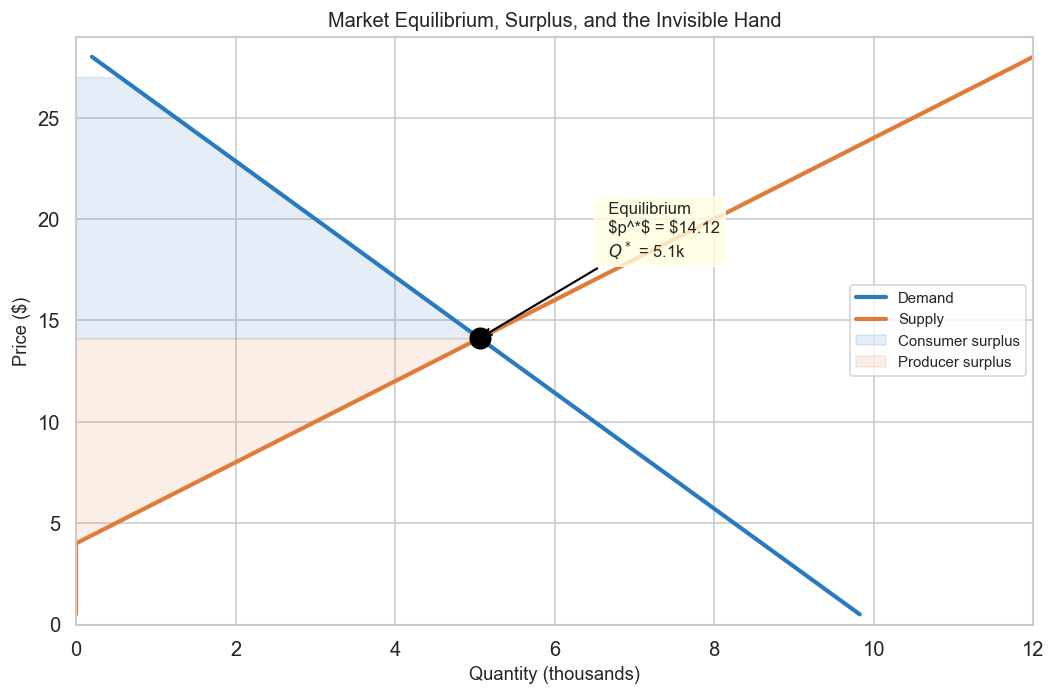

Equilibrium price    : $14.12
Equilibrium quantity : 5,059 units

Consumer surplus: the area between demand and the equilibrium price —
the total 'bargain' consumers capture by paying less than their max willingness.
Producer surplus: the corresponding gain for firms.
Together they measure total market welfare — what Smith's invisible hand delivers.


In [ ]:
## 1.3a  Market Equilibrium

# Analytical equilibrium: a - b*p = c + d*p  →  p* = (a - c) / (b + d)
p_star = (a_d - c_s) / (b_d + d_s)
q_star = demand(p_star)

fig, ax = plt.subplots(figsize=(9, 6))

# Price on Y, Quantity on X
Q_d = demand(prices)
Q_s = supply(prices)
ax.plot(Q_d / 1_000, prices, color="#2a7abf", lw=2.5, label="Demand")
ax.plot(Q_s / 1_000, prices, color="#e07b39", lw=2.5, label="Supply")

# Equilibrium point
ax.scatter([q_star / 1_000], [p_star], s=150, color="black", zorder=5)
ax.annotate(
    f"  Equilibrium\n  $p^*$ = ${p_star:.2f}\n  $Q^*$ = {q_star/1000:.1f}k",
    xy=(q_star / 1_000, p_star),
    xytext=(q_star / 1_000 + 1.5, p_star + 4),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.3),
    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8))

# Consumer surplus: area between demand and p* (to the LEFT of equilibrium on this axis layout)
p_cs = np.linspace(p_star, 27, 100)
Q_cs = demand(p_cs)
ax.fill_betweenx(p_cs, Q_cs / 1_000, 0,
                 where=Q_cs > 0, alpha=0.12, color="#2a7abf",
                 label="Consumer surplus")

# Producer surplus: area between p* and supply curve
p_ps = np.linspace(c_s / d_s * -1 + 0.1, p_star, 100)  # supply > 0 range
Q_ps = supply(p_ps)
ax.fill_betweenx(p_ps, Q_ps / 1_000, 0,
                 where=Q_ps > 0, alpha=0.12, color="#e07b39",
                 label="Producer surplus")

ax.set_ylabel("Price ($)", fontsize=11)
ax.set_xlabel("Quantity (thousands)", fontsize=11)
ax.set_title("Market Equilibrium, Surplus, and the Invisible Hand", fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 29)
ax.set_xlim(0, 12)

plt.tight_layout()
plt.savefig("fig_03_equilibrium.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Equilibrium price    : ${p_star:.2f}")
print(f"Equilibrium quantity : {q_star:,.0f} units")
print(f"\nConsumer surplus: the area between demand and the equilibrium price —")
print(f"the total 'bargain' consumers capture by paying less than their max willingness.")
print(f"Producer surplus: the corresponding gain for firms.")
print(f"Together they measure total market welfare — what Smith's invisible hand delivers.")

## 1.4 Shocking the Equilibrium — Comparative Statics and the Feedback Loop

Equilibria do not stand still. When external conditions change — a new competitor enters, a recession hits consumer income, the government imposes a tariff — the demand curve, the supply curve, or both shift to new positions. The equilibrium moves: a new price $p^{\prime}$ and a new quantity $Q^{\prime}$ emerge where the shifted curves intersect. Microeconomists call the analysis of this movement **comparative statics**: comparing two equilibria, one before and one after a shock, to understand the direction and magnitude of the change.

The distinction between *shifts of a curve* and *movements along a curve* is crucial here. A demand shock (changed income, changed preferences, a viral social-media post) shifts the demand curve bodily left or right. A supply shock (changed input costs, new technology, a factory shutdown) shifts the supply curve. In either case, the equilibrium slides along the *other* curve to a new intersection point. The comparative statics question is always: which curve moved, in which direction, and where did the new equilibrium land?

### Supply-Side Shocks as Competitive Strategy

Sometimes a company doesn't just play by the rules — it changes them. Firms can deliberately shift the supply curve by cutting costs dramatically or flooding the market with capacity. When that happens, prices fall and everyone buys more. But competitors who can't keep up get pushed out.

Rockefeller's Standard Oil did this in the 1870s. They vertically integrated — controlled refining and transportation themselves — so their costs dropped far below everyone else. They used that cost advantage to dominate the market. OPEC did the opposite: by cutting production in the 1970s, they shifted the supply curve the other way and quadrupled oil prices.

Here's the thing though: both of these examples involved companies with serious market power — monopolies and cartels. That's not the clean competitive market we've been talking about. When firms can actually move markets, you need game theory to understand what's really happening. We'll get to that in Article 2, but the point is: supply-demand thinking is useful, but it's not the whole story when companies have real power.

This matters for anyone building demand models: prices falling while sales rise doesn't mean demand went up. Supply may have shifted instead. Treating a supply shock as a demand signal doesn't just introduce noise — it systematically biases your estimates in ways that compound over time. Knowing which curve moved is not a theoretical nicety. It is the problem.

### The Feedback Loop, Made Visible

For pricing data scientists, this is where the feedback loop we defined in the introduction becomes concrete. When a shock moves the equilibrium — say, a competitor's flash sale shifts your demand curve left — the new equilibrium lands on a *different point* of both curves. At that new point, the relationship between price and quantity is different, the optimal markup is different, and the revenue implications are different. If your pricing algorithm responds by adjusting price, that response is itself a shock to the competitor's demand, triggering *their* adjustment, and the cycle continues.

This is the circularity of price made visible: every shock propagates through the equilibrium, lands on a new point, and feeds back into the system. A pricing algorithm that does not account for this — that treats each period as independent — will chase equilibrium shifts instead of anticipating them. The microeconomic framework gives you the language to reason about *which* curve moved, *in which direction*, and *what the new equilibrium implies* — before your algorithm has to react.


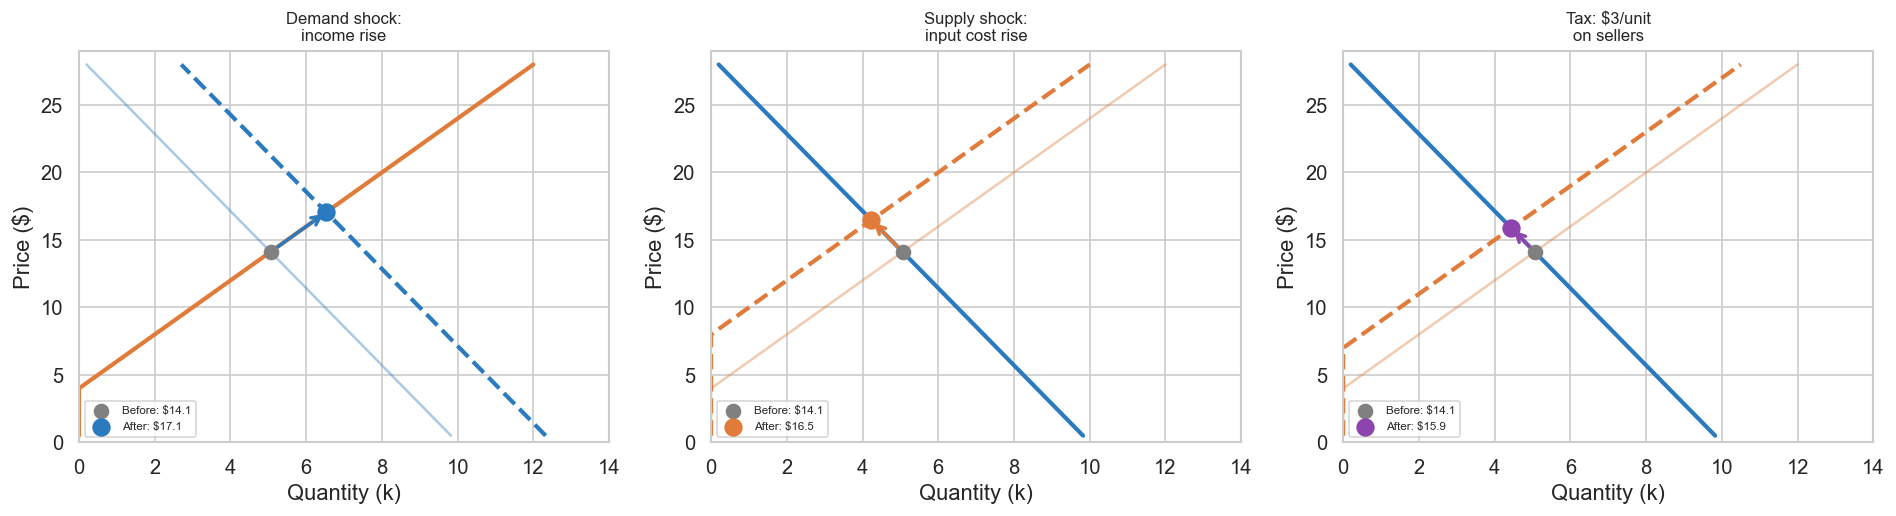

Each shock moves the equilibrium to a new point on both curves.
At the new point, elasticity differs, optimal pricing differs,
and the feedback loop carries the adjustment forward into the next period.


In [6]:
## 1.4a  Comparative Statics: Three Shocks

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

def find_eq(a, b, c, d):
    p = (a - c) / (b + d)
    q = max(a - b * p, 0)
    return p, q

shocks = [
    ("Demand shock:\nincome rise",
     (a_d, b_d, c_s, d_s),
     (a_d + 2500, b_d, c_s, d_s),
     "#2a7abf"),
    ("Supply shock:\ninput cost rise",
     (a_d, b_d, c_s, d_s),
     (a_d, b_d, c_s - 2000, d_s),
     "#e07b39"),
    ("Tax: $3/unit\non sellers",
     (a_d, b_d, c_s, d_s),
     (a_d, b_d, c_s - 3 * d_s, d_s),
     "#8e44ad"),
]

for ax, (title, before, after, color) in zip(axes, shocks):
    a0, b0, c0, d0 = before
    a1, b1, c1, d1 = after
    p0, q0 = find_eq(*before)
    p1, q1 = find_eq(*after)

    # Price on Y, Quantity on X
    Q_d0 = np.maximum(a0 - b0 * prices, 0)
    Q_s0 = np.maximum(c0 + d0 * prices, 0)
    Q_d1 = np.maximum(a1 - b1 * prices, 0)
    Q_s1 = np.maximum(c1 + d1 * prices, 0)

    ax.plot(Q_d0/1000, prices, color="#2a7abf", lw=1.5, alpha=0.4)
    ax.plot(Q_s0/1000, prices, color="#e07b39", lw=1.5, alpha=0.4)
    ax.plot(Q_d1/1000, prices, color="#2a7abf", lw=2.5, linestyle="--" if a1!=a0 else "-")
    ax.plot(Q_s1/1000, prices, color="#e07b39", lw=2.5, linestyle="--" if c1!=c0 else "-")

    ax.scatter([q0/1000], [p0], s=70, color="gray", zorder=5, label=f"Before: ${p0:.1f}")
    ax.scatter([q1/1000], [p1], s=100, color=color, zorder=5, label=f"After: ${p1:.1f}")
    ax.annotate("", xy=(q1/1000, p1), xytext=(q0/1000, p0),
                arrowprops=dict(arrowstyle="->", color=color, lw=2))

    ax.set_ylabel("Price ($)")
    ax.set_xlabel("Quantity (k)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_ylim(0, 29)
    ax.set_xlim(0, 14)

plt.tight_layout()
plt.savefig("fig_04_shocks.png", dpi=130, bbox_inches="tight")
plt.show()

print("Each shock moves the equilibrium to a new point on both curves.")
print("At the new point, elasticity differs, optimal pricing differs,")
print("and the feedback loop carries the adjustment forward into the next period.")

# 2. Elasticity — Where the Curves Begin to Speak Business

This is the section where the abstract geometry of supply and demand curves translates into the language that pricing teams, finance, and executives actually speak. The concept that does the translation is **elasticity** — a single number that summarises how sensitively one quantity responds to a percentage change in another.

If the demand curve tells you *what happens* when price changes, elasticity tells you *how much*. And that "how much" is what every pricing decision ultimately depends on.

## 2.1 Price Elasticity of Demand

The **price elasticity of demand** $\varepsilon_D$ is the percentage change in quantity demanded for a 1% change in price:

$$\varepsilon_D = \frac{\%\Delta Q_D}{\%\Delta p} = \frac{dQ_D}{dp} \cdot \frac{p}{Q_D}$$

When $|\varepsilon_D| > 1$: demand is **elastic** — consumers are sensitive. Raising price costs you more in volume than you gain in margin. When $|\varepsilon_D| < 1$: demand is **inelastic** — you have pricing power, and a moderate price increase raises revenue. When $|\varepsilon_D| = 1$: you sit at the **revenue-maximising point** where marginal revenue is zero.

## 2.2 Price Elasticity of Supply

The supply side has its counterpart: the **price elasticity of supply** $\varepsilon_S$ measures how responsive quantity supplied is to price:

$$\varepsilon_S = \frac{dQ_S}{dp} \cdot \frac{p}{Q_S}$$

For digital goods with near-zero marginal cost, supply elasticity is very high — you can serve one more subscriber for almost nothing. This asymmetry (highly elastic supply + variable demand) is what makes digital pricing so sensitive to demand-side estimation: the supply side barely constrains you, so everything turns on knowing the demand curve.

## 2.3 Cross-Price Elasticity and Substitution Patterns

Own-price elasticity is not the only elasticity that matters. In most real markets, your demand depends not just on your price but on competitors' prices. The **cross-price elasticity of demand** measures this interdependence:

$$\varepsilon_{ij} = \frac{\partial Q_i}{\partial p_j} \cdot \frac{p_j}{Q_i}$$

When $\varepsilon_{ij} > 0$, goods $i$ and $j$ are **substitutes** — a competitor's price increase sends customers to you. When $\varepsilon_{ij} < 0$, they are **complements**. Estimating cross-price elasticities is central to the Berry, Levinsohn, and Pakes (1995) framework for differentiated products, and it is often more actionable than own-price elasticity for competitive pricing decisions. We focus on own-price elasticity in this article for tractability, but a production pricing system that ignores substitution patterns is missing a critical dimension of the demand landscape.

## 2.4 How Shapes Matter

Elasticity is not a constant. It changes with price, with context, and — crucially — with the *functional form* of the demand curve. Your model choice encodes a hypothesis about how elasticity varies across the price range, and that hypothesis carries strategic consequences:

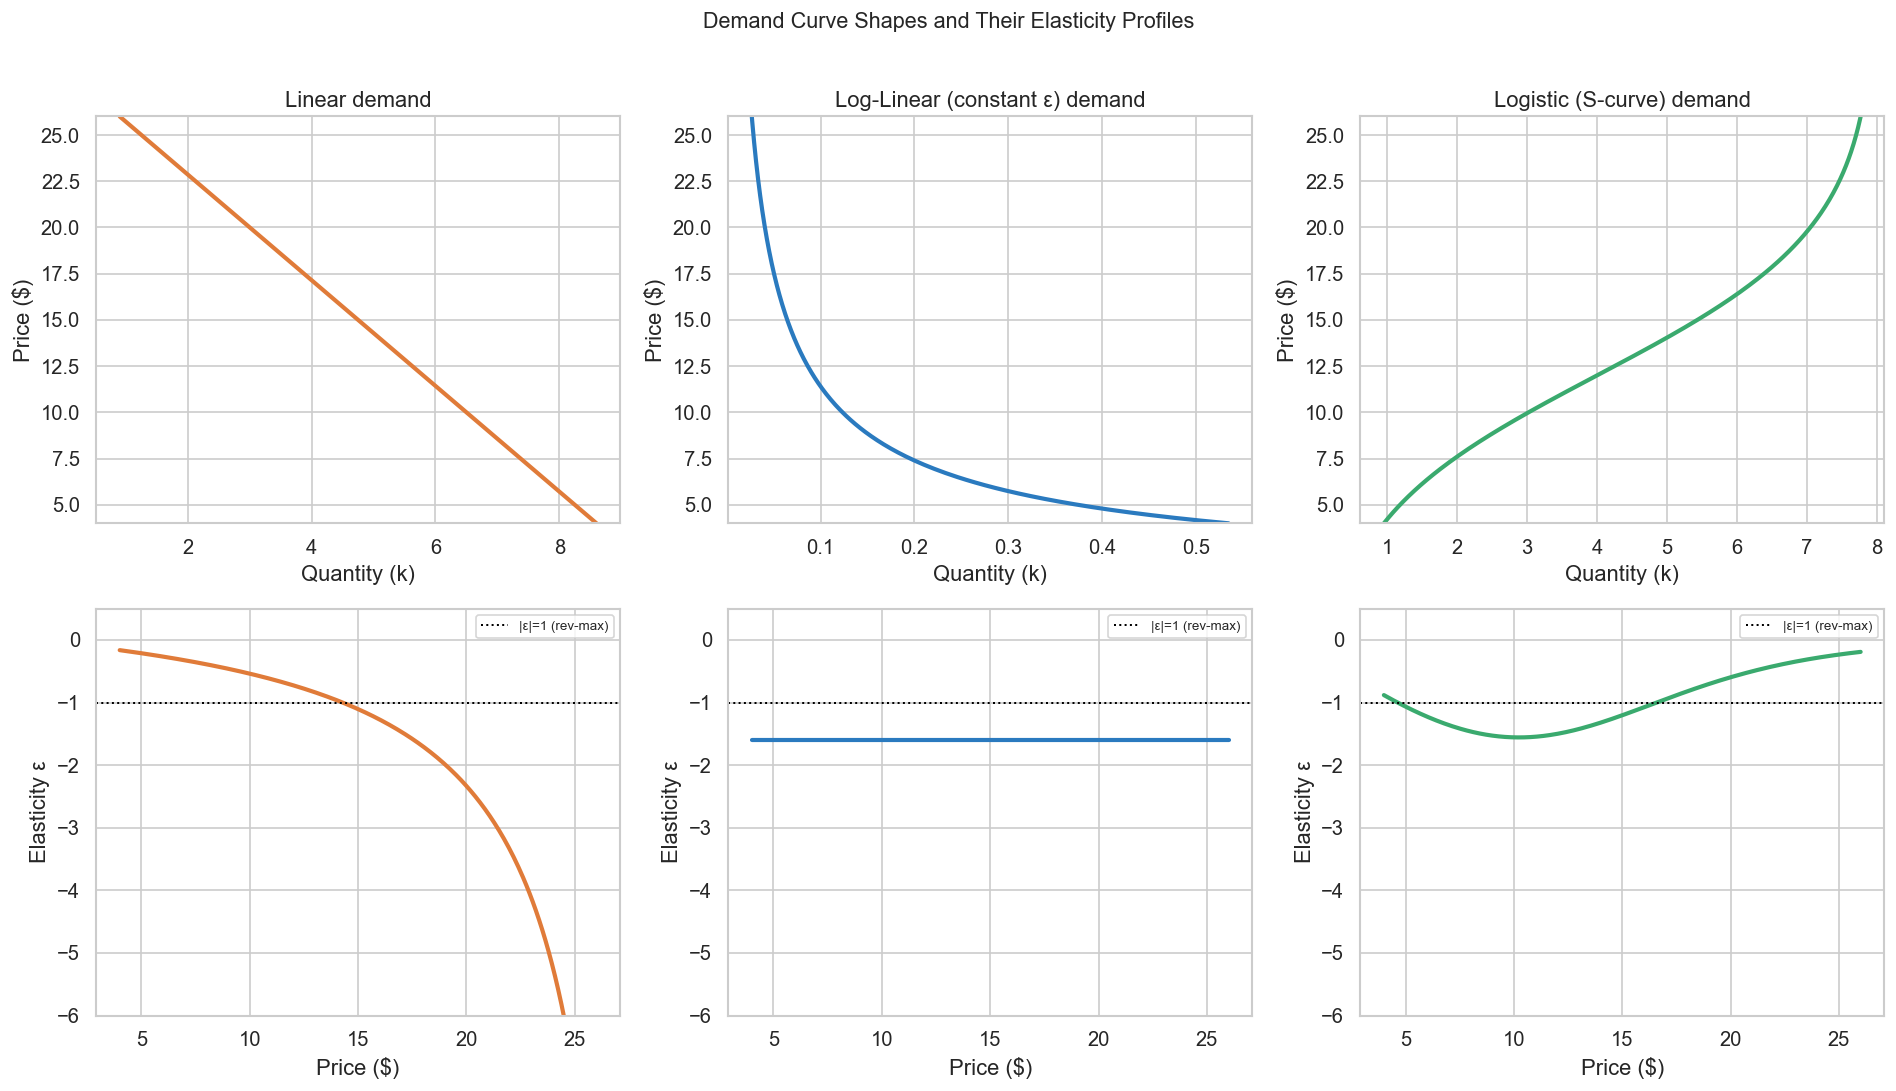

Your model choice is a hypothesis about market structure.
Linear: ε at $8 ≠ ε at $22. Log-linear: ε identical everywhere.
Logistic: most elastic mid-market, compressed at ceiling/floor.
The strategic implications of these differences are enormous.


In [7]:
## 2.3a  Three Demand Curve Shapes and Their Elasticity Profiles

prices_e = np.linspace(4.0, 26.0, 300)

# 1. Linear: Q = a - b*p → ε = -b*p / (a - b*p)
a_lin, b_lin = 10_000, 350
def Q_linear(p):  return np.maximum(a_lin - b_lin * p, 0)
def eps_linear(p):
    Q = Q_linear(p)
    return np.where(Q > 0, -b_lin * p / Q, np.nan)

# 2. Log-linear: log Q = α + β·log p → ε = β (constant)
alpha_ll, beta_ll = 8.5, -1.6
def Q_loglin(p):  return np.exp(alpha_ll + beta_ll * np.log(p))
def eps_loglin(p): return np.full_like(p, beta_ll)

# 3. Logistic: Q = K / (1 + exp(a - b*p))
K_s, a_s, b_s = 8_000, 3.0, 0.25
def Q_logistic(p): return K_s / (1 + np.exp(a_s - b_s * p))
def eps_logistic(p):
    Q = Q_logistic(p)
    dQdp = -K_s * b_s * np.exp(a_s - b_s * p) / (1 + np.exp(a_s - b_s * p))**2
    return dQdp * p / Q

models = [
    ("Linear", Q_linear, eps_linear, "#e07b39"),
    ("Log-Linear (constant ε)", Q_loglin, eps_loglin, "#2a7abf"),
    ("Logistic (S-curve)", Q_logistic, eps_logistic, "#3aaa6e"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col, (label, Q_fn, eps_fn, color) in enumerate(models):
    # Row 0: Demand (price on Y-axis)
    ax = axes[0, col]
    ax.plot(Q_fn(prices_e) / 1000, prices_e, color=color, lw=2.5)
    ax.set_ylabel("Price ($)")
    ax.set_xlabel("Quantity (k)")
    ax.set_title(f"{label} demand")
    ax.set_ylim(4, 26)

    # Row 1: Elasticity profile
    ax = axes[1, col]
    ax.plot(prices_e, eps_fn(prices_e), color=color, lw=2.5)
    ax.axhline(-1, color="black", linestyle=":", lw=1.2, label="|ε|=1 (rev-max)")
    ax.set_xlabel("Price ($)")
    ax.set_ylabel("Elasticity ε")
    ax.set_ylim(-6, 0.5)
    ax.legend(fontsize=8)

plt.suptitle("Demand Curve Shapes and Their Elasticity Profiles", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fig_05_elasticity.png", dpi=130, bbox_inches="tight")
plt.show()

print("Your model choice is a hypothesis about market structure.")
print("Linear: ε at $8 ≠ ε at $22. Log-linear: ε identical everywhere.")
print("Logistic: most elastic mid-market, compressed at ceiling/floor.")
print("The strategic implications of these differences are enormous.")

## 2.4  Elasticity Is the Most Important — and Hardest — Quantity to Estimate

This is the crux of the entire article.

Every pricing strategy, whether the team building it uses the formula or not, is an implicit attempt to solve the **Lerner markup condition**:

$$\frac{p - MC}{p} = \frac{1}{|\varepsilon_D|}$$

The more inelastic the demand, the higher the markup. The more elastic, the tighter the margin. To make this concrete: if your marginal cost is \$8 per unit and you estimate $|\varepsilon_D| = 2$, the Lerner condition prescribes a markup of 50%, yielding an optimal price of \$16. If demand is more elastic at $|\varepsilon_D| = 4$, the markup drops to 25% and the optimal price falls to \$10.67. Every unit of error in your elasticity estimate translates directly into mispricing. The equation is simple. The difficulty is entirely in estimating $\varepsilon_D$ — and, in practice, in knowing your marginal cost $MC$ with sufficient precision, which for digital goods approaches zero and for physical goods varies with scale, capacity utilisation, and input prices.

And that difficulty is *deep*. To estimate the price elasticity of demand, you need to observe how quantity changes when price changes **for causal reasons**. That means you need price variation that comes from outside the demand system — shocks that move price without also moving the quantity demanded for unrelated reasons. In the econometric literature, these are called **instruments**, and finding good ones has been the central challenge of empirical demand estimation since Philip Wright's landmark 1928 study of the flaxseed and butter markets.

Wright's breakthrough was realizing he could use a side door to solve his problem. He couldn't directly observe the demand curve because price and quantity always moved together — demand shocks and supply shocks mixed them up. But what if he found a variable that shifted only supply, leaving demand untouched? Weather does this. Bad weather reduces the harvest, shifting the supply curve left. Consumers still want flaxseed (demand doesn't change), but less is supplied at every price point. So the equilibrium moves along the demand curve: higher price, lower quantity. By comparing years with good weather to years with bad weather, Wright could see how the demand curve actually responded to price. That's an instrument: a variable that moves one curve without directly affecting the other. It's like pulling on the supply curve while demand stands still, so you can see demand's true shape. The same logic works backwards — a variable that shifts only demand (like consumer income) would trace out the supply curve.

Why is this so hard in practice? Because in the real world, price and quantity are **simultaneously determined by the intersection of supply and demand**. A naive regression of $Q$ on $p$ using observational data does not trace out the demand curve. It traces out a confused mixture of equilibrium points, generated by both demand and supply shocks moving both curves at once. The slope you recover is neither the demand elasticity nor the supply elasticity — it is a biased combination of both. This is the **simultaneous equations bias** that every econometrics course warns about, and it bites hard in pricing applications.

To make matters worse, **elasticity is not static**. It changes with the competitive environment, the stage of the product lifecycle, the macroeconomic cycle, and seasonal rhythms. Even if you could perfectly identify the demand curve today, it may shift by next quarter. Any system that relies on elasticity for pricing decisions must *continuously re-estimate* — which means you need a continuous stream of exogenous price variation.

This is where the connection to the next section becomes inevitable — but it takes two distinct forms, and it is worth being precise about which is which.

The first form is **dynamic pricing**. Algorithms like Thompson Sampling bandits actively set prices and observe what happens — and during their exploration phase, they assign prices based on internal uncertainty rather than current market conditions. That's not quite a randomised experiment, but it's closer than most observational data: the price variation has some independence from the demand shocks that would otherwise confound it. In that sense, a dynamic pricing agent is also, quietly, an experimenter — generating usable price variation as a byproduct of trying to learn. The parallel to instrumental variables isn't exact, since the identification here is experimental rather than structural, but the underlying logic is the same: to see the demand curve clearly, you need price to move for reasons other than demand itself.

The second form comes from the field of **heterogeneous treatment effect estimation** — a branch of causal inference concerned with measuring how the effect of a treatment (here, a price change) varies across units (customers, time periods, market conditions). The central question is: *what is the causal effect of price on quantity, and how does that effect differ across observable contexts?* This is precisely the elasticity estimation problem dressed in the language of potential outcomes.

Within this field, a family of methods has emerged for estimating treatment effects from observational data — settings where the treatment (price) was not randomly assigned but was influenced by confounders. These methods include targeted maximum likelihood estimation (TMLE), causal forests (Athey and Imbens, 2018), and a range of semiparametric estimators. Among them, **Double Machine Learning** (Chernozhukov et al., 2018) has become the reference implementation: it is widely adopted, theoretically well-grounded, and — crucially for practitioners — it integrates naturally with the ML tools data scientists already use.

DML is not a data-science invention. It was built by econometricians and statisticians, and its intellectual lineage runs straight back to Wright's instrumental variables, the Frisch–Waugh–Lovell theorem, and the semiparametric efficiency theory of Bickel, Klaassen, Ritov, and Wellner. What makes DML a natural bridge between the fields is that it wraps this econometric machinery in an ML-compatible interface: the nuisance functions are estimated with gradient-boosted trees, random forests, or neural nets, and the whole pipeline plugs into scikit-learn. DML does not generate causal variation; it *extracts* causal signal from data where the variation already exists but is confounded by observable factors.

Both approaches produce the same object — an estimate of the demand curve's slope — through complementary strategies. The dynamic pricer produces the experiment; DML extracts signal from observational residue. Understanding which tool applies to your setting (can you experiment, or must you work with observational data?) is one of the most consequential decisions a pricing data scientist makes.

We will see both play out concretely in the next section.


# 3. Price Setting in Practice

We now shift perspective. Sections 1 and 2 built the microeconomic machinery — demand, supply, equilibrium, elasticity, identification. This section asks: how do practitioners actually *set prices* in production, and how do those approaches connect to the theory?

The transition matters because it is not obvious. The pricing-algorithms literature and the microeconomics literature developed in parallel, with different vocabularies, different assumptions, and different success criteria. A Thompson Sampling paper optimises regret; a demand estimation paper optimises bias and coverage. Both are talking about the same underlying object — the demand curve — but neither typically acknowledges the other.

We examine two implementations that map directly onto the two forms of the identification problem we just described:

1. **Multi-Armed Bandits (MAB) with covariates** represent the *online, interventionist* approach. The algorithm actively sets prices, observes outcomes, and learns — this is **dynamic pricing** in its purest form. It directly maps onto the feedback loop we described in the introduction, and it generates its own instrumental variation.

2. **Double Machine Learning (DML)** represents the *offline, observational* approach. Given a historical dataset where prices were set by some (possibly confounded) process, DML recovers the causal price elasticity by residualising confounders. This is the **econometrician's problem** — demand estimation from panel data — translated into an ML-compatible pipeline. DML was not born in data science; it was conceived by Chernozhukov, Chetverikov, Demirer, Duflo, Hansen, Newey, and Robins — all econometricians or statisticians — and published in *The Econometrics Journal* in 2018. Data scientists adopted it because it wraps the Frisch–Waugh–Lovell theorem in a scikit-learn interface. Calling DML a 'data science technique' would be like calling calculus a 'physics technique' because physicists use it daily. The provenance matters: DML carries deep econometric assumptions about identification, and using it responsibly requires understanding those assumptions.

## 3.1 Multi-Armed Bandits: The Online Dynamic Pricer

### The Decision Problem

At each period $t = 1, \ldots, T$, the pricing agent observes a context vector $x_t \in \mathcal{X}$ (day of week, customer segment, inventory level, competitor price index) and must choose a price $p_t$ from a discrete set of arms $\mathcal{A} = \{p_1, \ldots, p_K\}$. After setting the price, the agent observes a stochastic reward $r_t = p_t \cdot Y_t$, where $Y_t \in \{0, 1\}$ indicates whether the customer purchased. The objective is to maximise cumulative revenue over the horizon $T$:

$$\max_{\{p_t\}_{t=1}^T} \; \mathbb{E}\left[\sum_{t=1}^{T} p_t \cdot Y_t\right]$$

### Regret: The Measure of Learning Cost

The fundamental tension is **exploration vs. exploitation**: the agent must balance testing unfamiliar prices (exploration, to learn the demand curve) against choosing the price it currently believes is best (exploitation, to earn revenue now). The cost of learning is measured by **cumulative regret** — the difference between the revenue an oracle policy would have earned and the revenue the learning agent actually earns:

$$R_T = \sum_{t=1}^{T} \left[ r_t^{*}(x_t) - r_t \right]$$

where $r_t^{*}(x_t) = \max_{k} \, p_k \cdot \mathbb{P}(Y_t = 1 \mid p_k, x_t)$ is the expected reward of the best arm in context $x_t$. A good algorithm achieves **sublinear regret**: $R_T = O(\sqrt{T \log T})$, meaning the average per-round regret vanishes as $T$ grows. In practical terms, the algorithm converges to the optimal price and the cost of exploration becomes negligible.

### Thompson Sampling: The Bayesian Resolution

Thompson Sampling (Thompson, 1933) resolves the exploration–exploitation dilemma through **posterior sampling**. The mechanism is elegant:

1. **Maintain a posterior** $\pi_t(\theta_k \mid \mathcal{H}_t)$ over the reward parameter $\theta_k$ of each arm $k$, given history $\mathcal{H}_t = \{(x_s, p_s, r_s)\}_{s=1}^{t-1}$.
2. **Sample** $\hat{\theta}_k \sim \pi_t(\theta_k)$ for each arm.
3. **Play** the arm with the highest sampled expected reward: $p_t = \arg\max_k \, p_k \cdot g(\hat{\theta}_k, x_t)$, where $g$ maps parameters and context to purchase probability.
4. **Update** the posterior with the observed outcome $(p_t, r_t)$ via Bayes' rule.

For binary purchase outcomes, a natural choice is a **Beta-Bernoulli model**: each arm $k$ in each context $c$ has a purchase probability $\theta_{k,c} \sim \text{Beta}(\alpha_{k,c}, \beta_{k,c})$. After observing a purchase, $\alpha_{k,c} \leftarrow \alpha_{k,c} + 1$; after no purchase, $\beta_{k,c} \leftarrow \beta_{k,c} + 1$. The posterior concentrates as evidence accumulates, and exploration naturally decays — arms with tight posteriors are exploited; arms with wide posteriors are explored, because their samples occasionally exceed the current best.

### Why Thompson Sampling Works

What makes Thompson Sampling appealing is not just that it explores, but how it explores. Rather than following an explicit schedule — forcing random prices every tenth period, say, as ε-greedy does — exploration emerges naturally from uncertainty: when the algorithm doesn't know which price performs best, the posterior is wide, and sampling from it produces varied prices almost automatically. As the algorithm learns, the posterior narrows, exploration fades, and the agent settles toward the revenue-maximising price. Agrawal and Goyal (2013) formalised this intuition: Thompson Sampling achieves O(ln T) frequentist regret per arm, matching the Lai–Robbins lower bound — meaning it converges to the optimal price at the fastest rate any algorithm could, given that it must learn entirely from its own experience.

That last phrase is worth holding onto. The algorithm learns from its own experience — which means every price it sets during exploration is also, from an econometric standpoint, an observation. Each price was chosen partly for reasons internal to the algorithm's uncertainty, not purely in response to market conditions. That partial independence is what gives the exploration phase its identification value. Within each context stratum, the prices the algorithm assigns trace out points along the demand curve — not because it was designed as an experiment, but because uncertainty-driven exploration produces something structurally close to one. The exploitation phase then harvests what that inadvertent experiment revealed.

**Implementation note**. The code that follows (Cell 3.1a) implements a simplified version: separate Beta posteriors for each arm in each context stratum (weekday vs. weekend). This is technically a partitioned standard bandit — the contexts are handled by maintaining independent models per stratum, not by sharing information across contexts through a parametric reward model. A production system with many context features would use a contextual bandit (LinTS, NeuralTS) that generalises across contexts via a parametric or neural reward function. We use the partitioned version for a didactical sake: it makes the Bayesian update mechanics visible without the machinery of linear algebra or neural network training

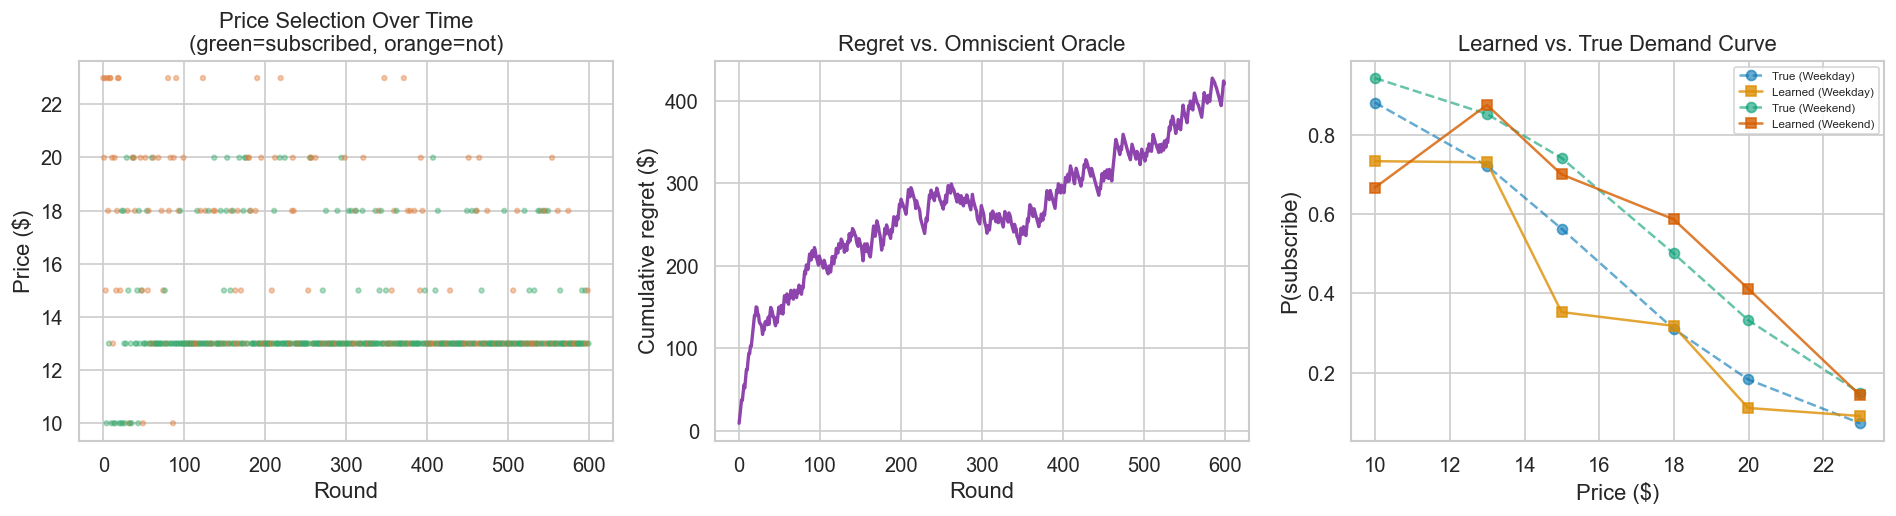

The bandit learns the demand curve through experimentation.
Regret flattens as it concentrates on near-optimal prices.
Each exploration step is an observation on the demand curve —
exactly the exogenous price variation economists need for identification.


In [8]:
## 3.1a  Thompson Sampling for Dynamic Pricing

# Arms = discrete price levels. Covariates = day type.
# Reward = revenue = price × 1[subscriber].

def true_subscribe_prob(price, weekend):
    logit = 5.5 - 0.35 * price + 0.8 * weekend
    
    return 1 / (1 + np.exp(-logit))

price_arms = np.array([9.99, 12.99, 14.99, 17.99, 19.99, 22.99])
n_arms = len(price_arms)

# Beta priors per (arm, context)
alpha_ts = np.ones((n_arms, 2))
beta_ts  = np.ones((n_arms, 2))

n_rounds = 600
cum_rev = np.zeros(n_rounds)
cum_opt = np.zeros(n_rounds)
chosen_prices = []
subscribed_list = []

for t in range(n_rounds):
    ctx = int(rng.random() > 0.7)
    samples = rng.beta(alpha_ts[:, ctx], beta_ts[:, ctx])
    expected_rev = samples * price_arms
    arm = np.argmax(expected_rev)
    p_chosen = price_arms[arm]

    p_sub = true_subscribe_prob(p_chosen, ctx)
    sub = rng.random() < p_sub
    reward = p_chosen * sub

    if sub: alpha_ts[arm, ctx] += 1
    else:   beta_ts[arm, ctx] += 1

    opt = max(pa * true_subscribe_prob(pa, ctx) for pa in price_arms)
    cum_rev[t] = cum_rev[t-1] + reward if t > 0 else reward
    cum_opt[t] = cum_opt[t-1] + opt if t > 0 else opt
    chosen_prices.append(p_chosen)
    subscribed_list.append(sub)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Price selection over time
ax = axes[0]
colors_scat = ["#3aaa6e" if s else "#e07b39" for s in subscribed_list]
ax.scatter(range(n_rounds), chosen_prices, c=colors_scat, s=8, alpha=0.4)
ax.set_xlabel("Round")
ax.set_ylabel("Price ($)")
ax.set_title("Price Selection Over Time\n(green=subscribed, orange=not)")

# Cumulative regret
ax = axes[1]
ax.plot(cum_opt - cum_rev, color="#8e44ad", lw=2)
ax.set_xlabel("Round")
ax.set_ylabel("Cumulative regret ($)")
ax.set_title("Regret vs. Omniscient Oracle")

# Learned vs true demand
ax = axes[2]
for ctx_label, ctx_val in [("Weekday", 0), ("Weekend", 1)]:
    learned = alpha_ts[:, ctx_val] / (alpha_ts[:, ctx_val] + beta_ts[:, ctx_val])
    true_r = [true_subscribe_prob(p, ctx_val) for p in price_arms]
    ax.plot(price_arms, true_r, "o--", label=f"True ({ctx_label})", alpha=0.6)
    ax.plot(price_arms, learned, "s-", label=f"Learned ({ctx_label})", alpha=0.8)
ax.set_xlabel("Price ($)")
ax.set_ylabel("P(subscribe)")
ax.set_title("Learned vs. True Demand Curve")
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("fig_06_thompson.png", dpi=130, bbox_inches="tight")
plt.show()

print("The bandit learns the demand curve through experimentation.")
print("Regret flattens as it concentrates on near-optimal prices.")
print("Each exploration step is an observation on the demand curve —")
print("exactly the exogenous price variation economists need for identification.")

## 3.2 Double Machine Learning: The Econometric Backbone

What if you cannot run experiments? You inherit a year of historical transaction data where prices were set by a human merchandiser reacting to demand conditions. Price is endogenous — correlated with unobserved demand shifters. OLS is biased.

This is the classic setting for **heterogeneous treatment effect estimation** from observational data: you have a treatment $T$ (log price), an outcome $Y$ (log quantity), and a vector of observed confounders $W$ (seasonality, marketing spend, competitor price index, and their interactions). You want the causal effect of $T$ on $Y$, which in our case is the price elasticity $\theta$.

### The Intuition: Regressions on Regressions

Double Machine Learning begins with a surprisingly familiar idea: residualisation. If you can predict both the outcome and the treatment from the confounders, then the parts of $Y$ and $T$ that the confounders cannot explain — the residuals — carry the causal signal you are after. Everything else is, in a sense, noise that the confounders already account for.

This intuition has a precise name in econometrics: the Frisch–Waugh–Lovell (FWL) theorem (Frisch and Waugh, 1933; Lovell, 1963). FWL says that in a linear regression of $Y$ on $T$ and $W$, the coefficient on $T$ is identical to the coefficient you get by: (1) regressing $Y$ on $W$ and taking residuals $\tilde{Y}$, (2) regressing $T$ on $W$ and taking residuals $\tilde{T}$, and (3) regressing $\tilde{Y}$ on $\tilde{T}$. The two-step residualisation produces the same estimate as the full regression — but it partials out the confounders, leaving only the variation in treatment and outcome that is orthogonal to $W$.

Why does this matter? Because $\tilde{T}$ represents the part of price variation that cannot be predicted by observed confounders. If $W$ captures all the relevant confounders — which is the identifying assumption the entire procedure rests on — then $\tilde{T}$ is effectively exogenous. And $\tilde{Y}$ is the part of quantity variation that isn't mechanically driven by those same confounders. The regression of $\tilde{Y}$ on $\tilde{T}$ recovers the causal elasticity because both sides have been cleaned of confounding.

The extension to nonlinear settings is not immediate. Replacing OLS in the first stage with flexible ML models — gradient-boosted trees, random forests, neural nets — introduces regularization bias: the first-stage models shrink and smooth their predictions in ways that distort the residuals, and that distortion propagates into the elasticity estimate. This is the problem DML (Chernozhukov et al., 2018) was built to solve, through two complementary ideas.

The first is Neyman orthogonality. The moment condition DML uses to identify $\theta$ is constructed so that small errors in estimating $E[Y|W]$ and $E[T|W]$ do not propagate into the elasticity estimate. The score is orthogonal to the nuisance parameters at their true values, which means regularization bias in the first stage leaves the second-stage estimate asymptotically intact.

The second is cross-fitting. The data is split into $K$ folds, and predictions for each fold are made by a model trained on the remaining folds. This prevents the ML models from overfitting to the same observations they are residualising — overfitting that would otherwise shrink the residuals and attenuate $\hat{\theta}$ toward zero.

Together, these two ideas make the procedure work. The DML estimator proceeds as follows:

1. Fit $\hat{m}(W) = \hat{E}[Y | W]$ and compute residuals $\tilde{Y} = Y - \hat{m}(W)$.
2. Fit $\hat{g}(W) = \hat{E}[T | W]$ and compute residuals $\tilde{T} = T - \hat{g}(W)$.
3. Regress $\tilde{Y}$ on $\tilde{T}$. The coefficient $\hat{\theta}$ is the causal elasticity.

The result is an estimator that is root-$n$ consistent and asymptotically normal, even when the nuisance functions are estimated with high-dimensional, regularized ML models. FWL provides the intuition; Neyman orthogonality and cross-fitting provide the guarantees that make it hold outside the linear world.

### Identification Conditions

DML produces reliable causal estimates only when specific conditions hold:

1. **Unconfoundedness (conditional independence):** $Y(t) \perp\!\!\perp T \mid W$ — conditional on observed confounders $W$, the treatment assignment is independent of potential outcomes. In pricing terms: after controlling for seasonality, marketing spend, competitor actions, and other observables, the remaining variation in price is as good as random.

2. **Overlap (positivity):** $0 < P(T = t \mid W) < 1$ for all $t$ and all values of $W$ in the support. Every combination of confounders must have some chance of receiving any treatment level. In practice, this means your data must contain price variation across all confounder strata — if certain customer segments always see the same price, you cannot identify the effect for those segments.

3. **Correct specification of confounders:** The confounder set $W$ must include all common causes of $T$ and $Y$. If an unobserved variable drives both price and quantity, the residuals $\tilde{T}$ are still confounded and $\hat{\theta}$ is biased.

These conditions are stated in the potential outcomes language of Rubin (1974), but checking them in practice requires knowing which variables belong in $W$ — a question the statistical framework cannot answer on its own. Judea Pearl's graphical framework gives a strategic way to do so: by making the assumed causal structure explicit as a directed acyclic graph (DAG), you can map the identification conditions onto a visual criterion that is easier to reason about when the data-generating process has economic structure. Concretely, $W$ must block all backdoor paths from $T$ to $Y$ in the causal DAG — that is, every path that connects price to quantity through a common cause. If you can draw the DAG of your pricing system — with nodes for price, quantity, seasonality, marketing spend, competitor actions, and unobserved demand shifters — and verify that conditioning on $W$ closes every backdoor path, then DML identifies the causal effect. If any backdoor path remains open, the estimate is biased regardless of how flexible your ML models are.

This is why economic reasoning is indispensable for DML: the statistical machinery is agnostic about which confounders to include. It is the microeconomic understanding of *what moves both supply and demand* that guides confounder selection and determines whether the identification conditions are plausible.


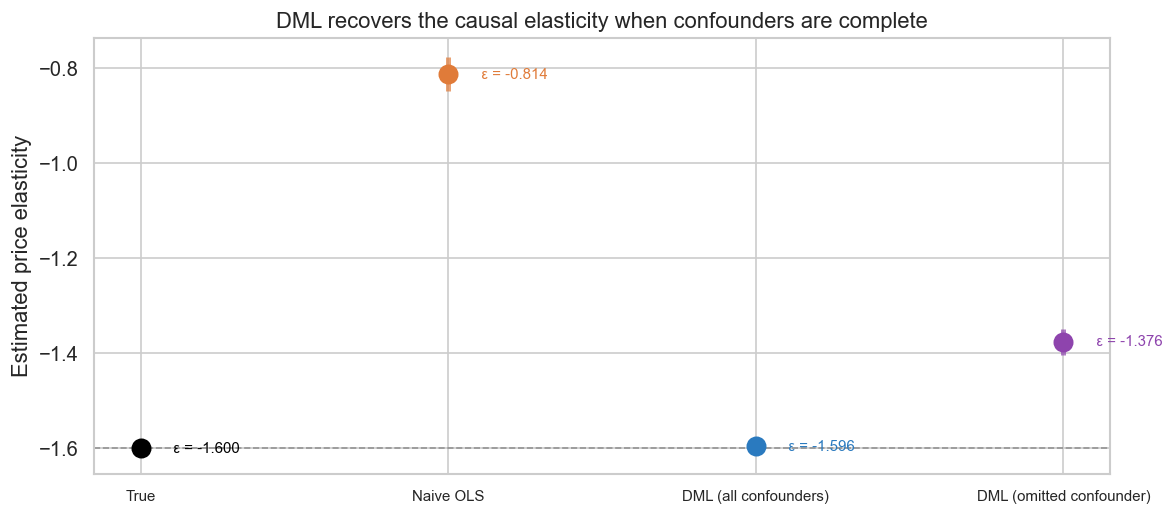

True ε             : -1.600
Naive OLS            : -0.814  (bias: 0.786)
DML (all confounders): -1.596  (bias: 0.004)
DML (omitted var)    : -1.376  (bias: 0.224)

Note: The DGP is linear, so Lasso first-stage models recover the nuisance
functions exactly. For nonlinear confounding, swap Lasso for GBR or random
forests — at the cost of requiring a larger sample for convergence.


In [9]:
## 3.2a  Double ML: Causal Elasticity from Confounded Data

n_dml = 2_000
rng_dml = np.random.default_rng(RANDOM_SEED + 1)
TRUE_ELAST = -1.6

# ── Confounders (affect both price and quantity) ────────────────
seasonality     = rng_dml.normal(0, 1, n_dml)
marketing_spend = rng_dml.normal(0, 1, n_dml)

# Unobserved demand shifter — the omitted variable for robustness check
unobs_demand = rng_dml.normal(0, 0.5, n_dml)

# ── Variables that affect price only (excluded instruments in IV parlance) ──
comp_price_idx = rng_dml.normal(0, 1, n_dml)   # competitor pricing
supply_cost    = rng_dml.normal(0, 0.3, n_dml)  # input costs

# ── Supply side: price is set by costs + demand pressure (simultaneity) ──
log_p_obs = (np.log(14.99)
             + 0.40 * marketing_spend     # marketing drives price up
             - 0.30 * comp_price_idx      # competitive pressure drives price down
             + 0.20 * seasonality          # seasonal pricing
             + 0.25 * unobs_demand         # demand pressure leaks into price
             + 0.15 * supply_cost          # cost pass-through
             + rng_dml.normal(0, 0.10, n_dml))

# ── Demand equation: quantity as a function of price + confounders ──
log_q_dml = (8.5
             + TRUE_ELAST * log_p_obs     # causal price effect (target)
             + 0.50 * seasonality          # seasonal demand
             + 0.30 * marketing_spend      # marketing lifts demand
             + 0.40 * unobs_demand         # unobserved taste shock
             + rng_dml.normal(0, 0.12, n_dml))

# ── Scenario 1: Naive OLS (biased by confounders AND simultaneity) ──
X_naive  = sm.add_constant(log_p_obs)
ols_res  = sm.OLS(log_q_dml, X_naive).fit()
naive_e  = float(ols_res.params[1])
ols_ci   = ols_res.conf_int(alpha=0.05)
naive_lo = float(ols_ci[1, 0])
naive_hi = float(ols_ci[1, 1])

# ── Scenario 2: DML with ALL confounders (oracle — knows unobserved) ──
# Only include true confounders (variables that affect both T and Y).
# comp_price_idx and supply_cost affect price only → not confounders.
# Including irrelevant controls hurts finite-sample performance (noise in
# nuisance estimates), so the oracle set is deliberately minimal.
W_oracle = np.column_stack([seasonality, marketing_spend, unobs_demand])
from sklearn.linear_model import Lasso
model_y  = Lasso(alpha=0.01, random_state=RANDOM_SEED)
model_t  = Lasso(alpha=0.01, random_state=RANDOM_SEED)
dml_oracle = LinearDML(model_y=model_y, model_t=model_t, cv=5,
                       random_state=RANDOM_SEED)
dml_oracle.fit(Y=log_q_dml, T=log_p_obs, X=None, W=W_oracle)
oracle_e  = float(dml_oracle.ate())
oracle_lo, oracle_hi = dml_oracle.ate_inference().conf_int_mean()
oracle_lo, oracle_hi = float(oracle_lo), float(oracle_hi)

# ── Scenario 3: DML with ONLY observed confounders (omitted variable) ──
W_partial = np.column_stack([seasonality, marketing_spend])
model_y2  = Lasso(alpha=0.01, random_state=RANDOM_SEED)
model_t2  = Lasso(alpha=0.01, random_state=RANDOM_SEED)
dml_partial = LinearDML(model_y=model_y2, model_t=model_t2, cv=5,
                        random_state=RANDOM_SEED)
dml_partial.fit(Y=log_q_dml, T=log_p_obs, X=None, W=W_partial)
partial_e  = float(dml_partial.ate())
partial_lo, partial_hi = dml_partial.ate_inference().conf_int_mean()
partial_lo, partial_hi = float(partial_lo), float(partial_hi)

# ── Visualise ──
fig, ax = plt.subplots(figsize=(10, 4.5))
labels = ["True", "Naive OLS", "DML (all confounders)", "DML (omitted confounder)"]
ests   = [TRUE_ELAST, naive_e,   oracle_e,  partial_e]
los    = [TRUE_ELAST, naive_lo,  oracle_lo, partial_lo]
his    = [TRUE_ELAST, naive_hi,  oracle_hi, partial_hi]
colors = ["black",    "#e07b39", "#2a7abf",  "#8e44ad"]

for i, (m, e, lo, hi, c) in enumerate(zip(labels, ests, los, his, colors)):
    ax.plot(i, e, "o", color=c, markersize=11, zorder=5)
    ax.vlines(i, lo, hi, color=c, lw=3, alpha=0.7)
    ax.annotate(f"  \u03b5 = {e:.3f}", xy=(i + 0.08, e), fontsize=9, color=c, va="center")
ax.axhline(TRUE_ELAST, color="black", linestyle="--", lw=1, alpha=0.3)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Estimated price elasticity")
ax.set_title("DML recovers the causal elasticity when confounders are complete")
plt.tight_layout()
plt.savefig("fig_07_dml.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"True \u03b5             : {TRUE_ELAST:.3f}")
print(f"Naive OLS            : {naive_e:.3f}  (bias: {abs(naive_e - TRUE_ELAST):.3f})")
print(f"DML (all confounders): {oracle_e:.3f}  (bias: {abs(oracle_e - TRUE_ELAST):.3f})")
print(f"DML (omitted var)    : {partial_e:.3f}  (bias: {abs(partial_e - TRUE_ELAST):.3f})")
print("\nNote: The DGP is linear, so Lasso first-stage models recover the nuisance")
print("functions exactly. For nonlinear confounding, swap Lasso for GBR or random")
print("forests — at the cost of requiring a larger sample for convergence.")


## 4. Connecting Both Worlds

Economists spent a century searching for instrumental variables — external shocks that move price without directly affecting demand — to identify the demand curve from observational data. Wright (1928) used supply-side cost shocks. Berry, Levinsohn, and Pakes (1995) used characteristics of competing  products. Each instrument was hard-won and dataset-specific. The underlying problem was always the same: the firm was a passive observer of market prices, so price and demand always moved together, and separating cause from correlation required a side door.

A dynamic pricing agent solves this problem differently — not by finding a better instrument, but by eliminating the need for one. When a bandit sets $p_t$ based on its internal posterior and random sampling, that price is a decision driven by the algorithm's state, not by market conditions. The firm is no longer a passive observer; it is an active experimenter. Wright searched for a variable that moved the supply curve while demand stood still. The bandit simply moves price directly, for reasons internal to its own uncertainty — and demand, unchanged by that internal state, responds. The demand curve becomes traceable not through a side door, but because the front door is now clean.

There are caveats. If the bandit's context vector $x_t$ includes variables that are themselves driven by demand — recent sales velocity, for instance — then price is no longer fully exogenous, and the experimental analogy breaks down: there is a backdoor path from demand conditions into the price assignment mechanism. Careful confounder selection in the context vector is therefore not just a modelling choice; it is what preserves the experimental integrity of the data.

The exploration phase is also where the identification value is concentrated. When the bandit is uncertain, it samples widely across the price space, tracing out points along the demand curve much as a randomised pricing experiment would. As the posterior narrows and exploitation dominates, price variation collapses near the estimated optimum. The data becomes less informative about the shape of the demand curve — not because the instrument weakens, but because the experiment has effectively ended. The bandit has learned what it needed to learn, and the cost is that the record it leaves behind is no longer rich enough for causal re-estimation.

From an economics perspective, this reframes what a pricing agent is: not just a revenue optimiser, but a system that generates quasi-experimental price variation at scale, continuously, as a byproduct of its own learning. From a data-science perspective, the economic reasoning explains why that exploration data is so valuable — it is the closest most firms will ever get to a stratified randomised pricing experiment, produced not by design, but by uncertainty.

## 4.1 Where Both Tools Fall Short

Microeconomic structure tells you not just how pricing algorithms work, but when they break.

DML identification requires all backdoor paths blocked. The three conditions from Section 3.2 — unconfoundedness, overlap, and correct confounder specification — are not merely technical assumptions. They are substantive claims about the causal structure of the market, and each has a concrete failure mode.

Unconfoundedness fails when an unmeasured variable jointly drives price and quantity after conditioning on $W$. In practice this is the hardest condition to defend: if a merchandiser raises prices because she observes rising demand that is not captured in $W$, the estimate is biased and no amount of ML flexibility fixes it. Overlap fails when a confounder stratum is deterministically associated with a single price — if your premium segment always sees $19.99, you learn nothing about its elasticity. Correct confounder specification fails in both directions: including a post-treatment variable like units sold biases the estimate; excluding a pre-treatment confounder like a competitor's promotional calendar does the same.

The bandit's failure mode is structural, not statistical. Thompson Sampling treats every reward signal as a demand signal. It has no model of supply, no concept of equilibrium, and no mechanism to distinguish a demand shock from a cost-structure shift. When a supply disruption raises the market price, the bandit observes lower quantity at higher price and updates its posterior — but in the wrong direction, confusing a supply-side event for information about demand shape.

Both tools, in other words, estimate pieces of the supply-demand system without modelling the system itself. Neither algorithmic convergence nor causal identification can be verified by data alone. They depend on structural assumptions about how the market works — assumptions that microeconomics provides the language to articulate, and that practitioners must defend before trusting the output.

# 5. The Frontier: From Classical Algorithms to Agentic Price Setting

The tools we have covered — MAB and DML — are powerful, but they share a set of limitations that surface quickly in real-world pricing:

1. Cold start. A bandit needs hundreds of interactions to converge. A new product has no history.
2. Unstructured context. A contextual bandit only knows what someone hardcoded into its feature pipeline — miss a signal at design time and it stays blind to it. The signal space is infinite and grows continuously: competitor moves, macroeconomic shifts, viral moments, supply disruptions. Deciding which signals matter requires ongoing domain judgment that does not scale with a static feature spec.
3. Static estimation. DML gives an average causal effect across the sample — it does not model how elasticity evolves, or how supply constraints bind differently at different volumes.
4. No supply-side reasoning. Neither MAB nor DML jointly models supply and demand. Neither can distinguish a demand shock from a supply shock in real time.
5. No interpretive reasoning. A bandit recommends $14.99. It cannot say why, or predict that the recommendation will change next week because a competitor is about to launch a substitute.

Each limitation is, at root, a limitation of scope: the classical tools are narrow specialists that do one thing well but cannot reason about the broader system. To address them, we need a framework that can orchestrate multiple tools, ingest heterogeneous information, and reason about the economic structure of the market — not just the statistical structure of the data.

This is the promise of agentic systems applied to pricing.

## 5.1 What Makes an Agent Different from a Pipeline

Before describing the architecture, it is worth being precise about what "agentic" means in this context — and what it does not.

A traditional ML pipeline is a fixed sequence: ingest data, featurise, predict, act. Each step is hard-coded. If the demand regime changes, the pipeline does not know — it continues to predict using the old model until a human notices and triggers a retrain. The pipeline cannot ask for additional data, cannot reason about whether its predictions are consistent with economic theory, and cannot explain its recommendations.

An agent, by contrast, is a system that perceives its environment, plans a course of action, acts, and then reflects on the outcome — adjusting its strategy based on what it learned. The distinction is not about model size or architecture; it is about the capacity for multi-step reasoning and tool use. An agent can call a forecasting model, examine the results, decide that the residuals look anomalous, run a change-detection test, conclude that a structural break has occurred, refit the demand model on a shorter window, and communicate the updated estimate — all without human intervention.

Ye et al. (2025) formalise this for time series in the Agentic Time Series Forecasting (ATSF) framework (arXiv:2602.01776). They organise the agentic workflow into five components:

- Perception: extracting informative features from raw data — not just numerical time series, but text (news, earnings calls), images (satellite data on store traffic), and structured signals (competitor price feeds).
- Planning: formulating a forecasting strategy given the perceived context. Should the agent use a short estimation window because a regime change is suspected? Should it include a new covariate that just became available?
- Action: invoking tools — running a DML estimation, calling a TimeFM forecast, querying a competitor price API, or executing a Thompson Sampling update.
- Reflection: evaluating the outcome. Did the forecast match reality? Was the bandit's regret trajectory consistent with the estimated demand curve? If not, what went wrong?
- Memory: accumulating experience across episodes. The agent remembers that the last time competitor X ran a flash sale, demand dropped 15% for three days
— and uses that memory to adjust its prior the next time it detects a similar signal.

Each component maps to an existing capability: perception is information retrieval and embedding; planning and reflection are the reasoning capacities of large language models; action is tool use via function calling; memory is retrieval-augmented generation or a vector store. What is new is the composition — organising these capabilities into a loop that can autonomously manage a pricing system.

## 5.2 The Two-Layer Architecture

How does this translate into a deployable system? The emerging pattern separates fast tactical pricing from slow strategic reasoning into two distinct layers with a clean interface between them.

Fast layer — the bandit. This is the Thompson Sampling engine from Section 3. It sits in the transaction path, prices in milliseconds, and exploits the current best estimate of the demand curve. It is reactive: it does not reason about why demand changed, only that it changed. Its state is compact — a set of Beta posteriors over price-arm conversion rates, stored in a low-latency parameter store (Redis or DynamoDB) and updated analytically with each transaction.

Slow layer — the agent. This is the reasoning core. It operates on a longer clock — hourly, daily, or event-triggered — and its job is to make the fast layer smarter. Crucially, it is not a pipeline. It is an LLM-based agent that perceives the current market state, plans a course of action, calls specialised tools to execute that plan, reflects on the results, and pushes updated priors to the fast layer. The economics lives inside the tools; the agent decides when to call them and what to do with the output.

The Agent's Tool Set

The slow layer agent has access to four tools:

Tool 1 — Signal retriever and classifier. Fetches structured signals (competitor prices, macroeconomic indicators, inventory levels) and unstructured signals (news feeds, social media, earnings call transcripts). The agent uses this tool to perceive the current demand and supply environment.Unstructured signals are embedded and retrieved via RAG; the agent classifies each signal as a demand shifter, supply shifter, or noise, and translates it into an economically-typed covariate — not free-form text passed to a black box, but a structured input with an explicit economic label.

Tool 2 — Regime detector. Runs change-detection tests (ADWIN, CUSUM, or Bayesian change-point models) on the bandit's regret trajectory and on the residuals of the current demand model. A sudden increase in regret suggests the demand curve has shifted. The agent calls this tool periodically and after any significant external signal, using the output to decide whether re-estimation is warranted.

Tool 3 — DML estimator. When the bandit's exploration window contains sufficient clean price variation, the agent calls the DML estimator to recover a causal elasticity estimate from that data. This is the identification engine from Section 3.2 — it requires the overlap and unconfoundedness conditions to hold, which the agent can partially verify by inspecting the distribution of residual price variation. The output is a point estimate and confidence interval for $\hat{\theta}$, the price elasticity of demand.

Tool 4 — TimeFM forecaster. Calls a fine-tuned TimeFM model to forecast the demand trajectory over the next planning horizon. TimeFM is a foundation model for time series, pretrained on a large corpus of temporal data; it can forecast from pattern recognition even with limited product history, which makes it particularly valuable during cold-start periods when the bandit's posteriors are still diffuse. The structured covariates produced by Tool 1 — competitor price changes, macroeconomic indicators, seasonal dummies — enter the TimeFM context window explicitly, making the signal ingestion mechanism transparent and auditable.

How External Signals Map to Supply-Demand Shifts

Every external signal the agent perceives is, in economic terms, a potential shift of the demand curve, the supply curve, or both. The agent's value is that it can reason about which curve moved and why — something the bandit, which sees only reward changes, cannot do.

| Signal type | Economic interpretation | Agent action |
|---|---|---|
| Competitor price cut | Demand shifts left (substitutes cheaper) | Adjust demand covariate downward; widen bandit exploration |
| Viral social mention | Demand shifts right (increased awareness) | Adjust demand covariate upward; consider price increase |
| Supply-chain disruption | Supply shifts left (capacity constrained) | Reduce quantity expectations; tighten price floor |
| Consumer confidence drop | Demand shifts left (income effect) | Lower demand forecast; increase exploration at lower prices |
| New regulatory cost | Supply shifts left (higher marginal cost) | Raise price floor to maintain margin |

The Interface Between Layers

The fast layer and slow layer communicate through a single shared object: the prior state stored in the parameter store. The slow layer reads transaction history and writes updated priors; the fast layer reads priors and writes new transactions. Neither layer needs to know the internal workings of the other.

The slow layer's update cycle is:

1. Perceive — call Tool 1 to retrieve and classify external signals
2. Assess — call Tool 2 to check for regime breaks
3. Re-estimate — if a break is detected or the exploration window is sufficient, call Tool 3 (DML) and Tool 4 (TimeFM)
4. Update — translate the combined outputs into updated Beta prior parameters and push to the parameter store
5. Explain — produce a structured natural-language summary for the human console

## 5.3 The Simplest Possible Implementation

What would a minimal but production-credible version of this system look like?

Components

Fast layer is a stateless pricing service. On each request it reads the current Beta posteriors from Redis, samples from them via Thompson Sampling, returns the recommended price, and — after the transaction resolves — posts the outcome back to a transaction queue. No ML inference happens in the request path. Latency is dominated by the Redis read, typically under 5ms.

Slow layer is a scheduled agent process, running as an Airflow DAG or event-triggered Lambda. Its entry point is an LLM with function-calling enabled — Claude, GPT-4o, or an open-weight equivalent deployed locally. The tools described in Section 5.2 are registered as callable functions. On each invocation the agent receives a context packet containing the latest transaction summary, current prior state, recent regret trajectory, and a retrieved set of external signals. It then reasons through the ATSF loop — perceive, plan, act, reflect — calling tools as needed, and terminates by writing updated priors to Redis and a structured assessment to the human console.

TimeFM runs as a separate microservice. The base model is pretrained; fine-tuning on domain-specific pricing data is optional at launch but becomes valuable once transaction volume exceeds a few thousand observations per product. Fine-tuning follows a standard supervised workflow: historical (price, quantity, covariates) tuples form the training set, with the price-quantity relationship as the target. The fine-tuned model is versioned and swapped in by the agent when validation metrics improve over the base model.

DML estimator is a Python function the agent calls directly. It takes a data window, a treatment column (log price), an outcome column (log quantity), and a confounder matrix, and returns a point estimate and confidence interval for elasticity. The implementation from Section 3.2 applies without modification — the agent simply decides when to call it and how wide a window to pass.

Human-in-the-loop console deserves more than a footnote. This is where the economic reasoning becomes legible to the pricing analyst. The console displays: the agent's natural-language assessment of the current demand regime; the posterior distributions over elasticity from the most recent DML run; the bandit's regret trajectory with annotated regime-change events; the external signals that triggered the most recent update, with their economic classification; and a price range recommendation with uncertainty bounds. Critically, it includes an override mechanism: the analyst can accept the recommendation, adjust the price range, or veto the update entirely and flag it for review. The agent recommends; the analyst decides. This is not a UX nicety — it is the control layer that makes the system auditable and correctable when the identification assumptions break down.

Critical Design Decisions

The hard choices in this system are not hyperparameters — they are economic design choices that the microeconomic framework we built throughout this article directly informs:

Update frequency. How often should the slow layer push new priors to the fast layer? Too frequently and you risk overfitting to noise; too infrequently and the bandit exploits a stale demand estimate after a regime change. The right cadence depends on the volatility of your demand environment — a daily consumer product warrants hourly updates; a B2B contract product may warrant weekly ones.

Exploration window length for DML. DML requires sufficient price variation to identify elasticity. If the bandit has converged and is exploiting a narrow price range, the overlap condition weakens and the DML estimate degrades. The agent should track the distribution of residual price variation in the current window and widen exploration — or flag to the analyst — when it falls below a minimum threshold.

Weight between DML and TimeFM. DML gives you causal elasticity — the structural parameter. TimeFM gives you demand trajectory — the level forecast. They answer different questions and should not be averaged. The correct combination is to use TimeFM to set the demand intercept (where the curve is) and DML to set the slope (how it responds to price). If the two are inconsistent — TimeFM forecasts rising demand but DML shows weakening elasticity — that inconsistency is itself a signal worth surfacing to the analyst.

Regime-change threshold. The sensitivity of the change-detection test determines how quickly the system responds to demand shifts versus how often it triggers false alarms. Tighter thresholds mean faster adaptation but more noise in the prior updates. This is, ultimately, a loss function question: what is the cost of a missed regime change versus the cost of an unnecessary re-estimation? The answer is product- and market-specific.


### 5.4 Conclusion

The architecture described here marks a qualitative shift in what pricing systems can do. Classical algorithms — bandits, DML estimators, demand models — are powerful but narrow: each solves one well-defined problem and hands the result to the next stage. An agentic system does something different. It perceives the market as an economist would, reasons across tools as a analyst would, and acts at the speed and scale that neither could achieve alone. Problems that previously required human judgment — detecting a regime change, classifying an external signal, deciding whether to re-estimate or hold — become automatable without becoming opaque. The result is not a faster pipeline. It is a system that can genuinely reason about price: what it should be, why it should change, and what the consequences of changing it are likely to be.

The architecture we have described is not a research prototype. Each component — Thompson Sampling, DML, TimeFM, LLM function calling, RAG-based signal retrieval — is available today as a production-grade library or API. What is new is the composition: organising these capabilities into a reasoning loop that can autonomously manage the identification problem we have traced throughout this article, from Wright's weather instrument to the demand curve the bandit continuously draws and redraws in real time.

In [ ]:
# ==========================================================================
#  5.5a  Minimal Agentic Pricing System - LangGraph Demo
#
#  pip install langgraph langchain langchain-openai numpy scipy
#
#  To change LLM, replace the one marked line:
#    ChatAnthropic(model="claude-opus-4-6").bind_tools(tools_list)
#    ChatOllama(model="llama3").bind_tools(tools_list)
#    ChatGroq(model="llama3-70b-8192").bind_tools(tools_list)
# ==========================================================================

import json, operator
import numpy as np
from scipy import stats
from dataclasses import dataclass, field
from typing import Annotated, List, Dict

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI          # <- swap this line to change LLM
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from typing_extensions import TypedDict


# ------------------------------------------------------------------
# SHARED STATE  (simulates Redis in production)
# ------------------------------------------------------------------

@dataclass
class MarketState:
    price_arms:   List[float] = field(default_factory=lambda: [9.99, 12.99, 14.99, 17.99, 19.99])
    arm_alphas:   List[float] = field(default_factory=lambda: [1.0] * 5)  # Beta successes
    arm_betas:    List[float] = field(default_factory=lambda: [1.0] * 5)  # Beta failures
    transactions: List[Dict]  = field(default_factory=list)
    last_assessment: str = ""

market = MarketState()  # global - in production this lives in Redis


# ------------------------------------------------------------------
# FAST LAYER  - Thompson Sampling (runs on every transaction)
# ------------------------------------------------------------------

def fast_price() -> tuple:
    """Sample Beta posteriors, return (price, arm_index). Simulates <5 ms Redis read."""
    samples = [np.random.beta(market.arm_alphas[i], market.arm_betas[i])
               for i in range(len(market.price_arms))]
    arm = int(np.argmax(samples))
    return market.price_arms[arm], arm

def fast_update(arm: int, converted: bool) -> None:
    """Update Beta posteriors after observing outcome."""
    if converted:
        market.arm_alphas[arm] += 1
    else:
        market.arm_betas[arm]  += 1
    market.transactions.append({"price": market.price_arms[arm], "converted": converted})


# ------------------------------------------------------------------
# SLOW LAYER TOOLS  - registered with the LangGraph agent
# ------------------------------------------------------------------

@tool
def retrieve_signals() -> str:
    """Retrieve and classify external market signals as demand or supply shifters."""
    # Mock - in production: competitor price feeds, news embeddings, macro APIs
    signals = [
        {"signal": "Competitor A cut price by 8%",     "type": "demand_shifter", "direction": "left",  "magnitude": -0.08},
        {"signal": "Consumer confidence index +2 pts", "type": "demand_shifter", "direction": "right", "magnitude":  0.02},
    ]
    return json.dumps(signals)

@tool
def detect_regime_change() -> str:
    """Run a CUSUM-style test on recent conversion rates to detect demand regime shifts."""
    txs = market.transactions
    if len(txs) < 10:
        return json.dumps({"regime_change": False, "reason": "insufficient data"})

    recent = txs[-10:]
    prior  = txs[-20:-10] if len(txs) >= 20 else recent
    r_rate = float(np.mean([t["converted"] for t in recent]))
    p_rate = float(np.mean([t["converted"] for t in prior]))
    shift  = abs(r_rate - p_rate)

    return json.dumps({
        "regime_change":    shift > 0.15,
        "recent_conv_rate": round(r_rate, 3),
        "prior_conv_rate":  round(p_rate, 3),
        "shift":            round(shift, 3),
    })

@tool
def estimate_elasticity() -> str:
    """
    Run a simplified DML estimator on the transaction log.
    Returns price elasticity point estimate and 95% CI.
    In production: replace with proper cross-fitted Double ML from Section 3.2.
    """
    txs = market.transactions
    if len(txs) < 20:
        return json.dumps({"error": "need >= 20 transactions", "available": len(txs)})

    log_p = np.log([t["price"]           for t in txs])
    conv  = np.array([float(t["converted"]) for t in txs])

    slope, _, _, p_val, se = stats.linregress(log_p, conv)
    return json.dumps({
        "elasticity": round(float(slope), 3),
        "ci_95":      [round(float(slope - 1.96 * se), 3), round(float(slope + 1.96 * se), 3)],
        "p_value":    round(float(p_val), 4),
        "n":          len(txs),
    })

@tool
def forecast_demand() -> str:
    """
    Forecast near-term demand (mocked TimeFM call).
    In production: POST to fine-tuned TimeFM microservice with covariate context.
    """
    txs      = market.transactions
    baseline = float(np.mean([t["converted"] for t in txs[-5:]])) if len(txs) >= 5 else 0.30
    trend    = "stable" if abs(baseline - 0.30) < 0.05 else ("rising" if baseline > 0.30 else "falling")
    return json.dumps({
        "demand_index": round(baseline * 100, 1),
        "trend":        trend,
        "note":         "mock TimeFM - replace with microservice call in production",
    })


# ------------------------------------------------------------------
# SLOW LAYER GRAPH  - LangGraph agent (runs on a slow clock)
# ------------------------------------------------------------------

class AgentState(TypedDict):
    messages: Annotated[list, operator.add]

tools_list = [retrieve_signals, detect_regime_change, estimate_elasticity, forecast_demand]

# -- LLM: swap this one line ------------------------------------------
llm = ChatOpenAI(model="gpt-4o", temperature=0).bind_tools(tools_list)
# llm = ChatAnthropic(model="claude-opus-4-6").bind_tools(tools_list)
# llm = ChatOllama(model="llama3").bind_tools(tools_list)
# ---------------------------------------------------------------------

SYSTEM_PROMPT = """You are a pricing agent. On each cycle, call all four tools in order:
1. retrieve_signals      - perceive the current market environment
2. detect_regime_change  - check whether demand has structurally shifted
3. estimate_elasticity   - recover a causal price-elasticity estimate
4. forecast_demand       - get a near-term demand trajectory

Then synthesise a concise analyst-facing assessment: current demand regime, elasticity
estimate with uncertainty, and a price recommendation with rationale."""

def agent_node(state: AgentState) -> AgentState:
    return {"messages": [llm.invoke(state["messages"])]}

def should_continue(state: AgentState) -> str:
    return "tools" if getattr(state["messages"][-1], "tool_calls", None) else "end"

# Build the graph: agent -> (tools -> agent)* -> END
graph = StateGraph(AgentState)
graph.add_node("agent", agent_node)
graph.add_node("tools", ToolNode(tools_list))
graph.set_entry_point("agent")
graph.add_conditional_edges("agent", should_continue, {"tools": "tools", "end": END})
graph.add_edge("tools", "agent")
slow_layer = graph.compile()

def run_slow_layer() -> str:
    result = slow_layer.invoke({
        "messages": [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=(
                f"Run a full pricing assessment. "
                f"Transactions logged: {len(market.transactions)}. "
                f"Call all four tools, then give your assessment."
            )),
        ]
    })
    assessment = result["messages"][-1].content
    market.last_assessment = assessment
    return assessment


# ------------------------------------------------------------------
# SIMULATION  - fast layer every transaction, slow layer every N
# ------------------------------------------------------------------

def simulate(n_transactions: int = 40, slow_every: int = 10) -> None:
    print("=" * 60)
    print("  Agentic Pricing System - Demo Simulation")
    print("=" * 60 + "\n")

    for i in range(n_transactions):
        price, arm = fast_price()

        # True demand: elasticity = -1.5, baseline conversion at $14.99 = 0.40
        true_prob = 0.40 * (price / 14.99) ** (-1.5)
        converted = bool(np.random.random() < true_prob)
        fast_update(arm, converted)

        print(f"[Fast] tx {i+1:02d}  price=${price:.2f}  converted={converted}")

        if (i + 1) % slow_every == 0:
            print(f"\n[Slow] -- agent cycle after {i+1} transactions --")
            assessment = run_slow_layer()
            print(f"[Slow] Assessment:\n{assessment}\n")
            print("-" * 60 + "\n")

simulate()

# What You Walk Away With

Price is endogenous. It is simultaneously a cause and an effect, shaping the system it measures and being shaped by it. That circularity is not a nuisance to be patched around — it is the defining characteristic of the variable, and understanding it changes how you build every pricing system.

The microeconomic framework gives you demand, supply, equilibrium, and elasticity — not as academic abstractions but as the structural equations that govern your pricing algorithm's environment. Elasticity is the most important and hardest quantity to estimate; its difficulty is the bridge that connects economic theory to algorithmic design.

The bridge runs in both directions. For data scientists, microeconomic theory provides the structural assumptions that explain why MAB converges, when DML is identified, and how to interpret a Bayesian posterior in business terms. For economists, modern pricing algorithms are the perfect instrumentalist tools — machines that produce clean, exogenous price variation at scale.

And where classical algorithms stop — at cold start, at unstructured context, at regime changes, at the full supply-demand dynamic — agentic systems pick up, using economic reasoning as their operating language and the posterior over elasticity as their shared interface.

### What This Article Does Not Cover

Several important dimensions of pricing are deliberately deferred. **Price discrimination** — personalised pricing, versioning, segment-based price schedules — is absent; we treat the single-price, single-product case throughout. **Strategic interaction** — Bertrand and Cournot competition, Nash equilibrium, best-response functions — is mentioned narratively but not formalised; these models explain why the Lerner markup differs under oligopoly and why the 'invisible hand' result fails when firms have market power. **Intertemporal demand** — consumers who anticipate future price changes and shift purchases across time — is omitted; strategic consumer behaviour invalidates the static demand curve and is particularly relevant for subscription and promotional pricing. **Welfare implications of algorithmic pricing** — tacit collusion via coordinated pricing agents (Calvano et al., 2020), fairness concerns around dynamic and personalised pricing — deserve serious treatment but exceed this article's scope. All of these are addressed in Article 2.

In Article 2, we break the single-agent frame and ask: *what happens when multiple intelligent pricing agents operate in the same market?*


## References

### Textbooks
- **Perloff, J.M.** — *Microeconomics* (8th ed.). Pearson.
- **Bishop, C.M.** — *Pattern Recognition and Machine Learning*. Springer.

### Foundational Papers
- **Wright, P.G. (1928)** — *The Tariff on Animal and Vegetable Oils*. Macmillan.
- **Berry, S., Levinsohn, J. & Pakes, A. (1995)** — *Automobile Prices in Market Equilibrium*. Econometrica.
- **Chernozhukov, V. et al. (2018)** — *Double/Debiased Machine Learning for Treatment and Structural Parameters*. [arXiv:1608.00060](https://arxiv.org/abs/1608.00060)
- **Conlon, C. & Gortmaker, J. (2020)** — *Best Practices for Differentiated Products Demand Estimation with PyBLP*. RAND J. Econ.

### Dynamic Pricing & Bandits
- **Misra, K. & Nair, H. (2011)** — *Dynamic Online Pricing with Incomplete Information Using MAB Experiments*. Marketing Science.
- **Ferreira, K.J., Simchi-Levi, D. & Wang, H. (2018)** — *Online Network Revenue Management Using Thompson Sampling*. [arXiv:1802.03050](https://arxiv.org/abs/1802.03050)
- **Ban, G.-Y. & Keskin, N.B. (2021)** — *Personalized Dynamic Pricing with Machine Learning*. Management Science.
- **Chen, X. & Wang, Y. (2024)** — *Contextual Dynamic Pricing*. [arXiv:2406.02424](https://arxiv.org/abs/2406.02424)
- **Agarwal, A. et al. (2025)** — *Parameter-Adaptive Dynamic Pricing*. [arXiv:2503.00929](https://arxiv.org/abs/2503.00929)

### DML & Causal Inference
- **Clarke, D., Luo, Y. & Poirier, A. (2024)** — *DML meets Panel Data*. [arXiv:2409.01266](https://arxiv.org/abs/2409.01266)
- **Athey, S. & Imbens, G. (2016)** — *Recursive Partitioning for Heterogeneous Causal Effects*. PNAS.
- **EconML** — [econml.azurewebsites.net](https://econml.azurewebsites.net/)

### Strategic Interaction & Welfare
- **Calvano, E. et al. (2020)** — *Artificial Intelligence, Algorithmic Pricing, and Collusion*. American Economic Review.
- **Kahneman, D., Knetsch, J.L. & Thaler, R.H. (1986)** — *Fairness as a Constraint on Profit Seeking*. American Economic Review.

### Agentic Time Series
- **Ye, Z. et al. (2025)** — *Beyond Model-Centric Prediction — Agentic Time Series Forecasting*. [arXiv:2602.01776](https://arxiv.org/abs/2602.01776)
- **DCATS (2025)** — *Empowering Time Series Forecasting with LLM-Agents*. [arXiv:2508.04231](https://arxiv.org/abs/2508.04231)
- **Li, Y. et al. (2025)** — *A Survey of Reasoning and Agentic Systems in Time Series with LLMs*. [arXiv:2509.11575](https://arxiv.org/abs/2509.11575)

### Bayesian Workflow
- **Gabry, J. et al. (2019)** — *Visualization in Bayesian Workflow*. JRSS-A.
- **PyMC** — [pymc.io](https://www.pymc.io/) · **ArviZ** — [python.arviz.org](https://python.arviz.org/)